In [1]:
import torch

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA Available : True
GPU : Tesla P100-PCIE-16GB


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [2]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 1 : Environment Setup
# ============================================================

import os
import gc
import sys
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

warnings.filterwarnings("ignore")

print("=" * 70)
print("NeuroAegis - EEG Seizure Detection")
print("=" * 70)

print(f"Python Version : {sys.version.split()[0]}")
print(f"Numpy          : {np.__version__}")
print(f"Pandas         : {pd.__version__}")

DATASET_PATH = Path("/kaggle/input/eegdata")

print("\nDataset Path:")
print(DATASET_PATH)

print("\nFolders Found:")

if DATASET_PATH.exists():
    folders = sorted([f.name for f in DATASET_PATH.iterdir() if f.is_dir()])
    print(folders)
else:
    print("Dataset not found!")

print("=" * 70)

NeuroAegis - EEG Seizure Detection
Python Version : 3.12.13
Numpy          : 2.0.2
Pandas         : 2.3.3

Dataset Path:
/kaggle/input/eegdata

Folders Found:
Dataset not found!


In [3]:
from pathlib import Path
import os

print("="*80)
print("Searching Kaggle Input Directory")
print("="*80)

base = Path("/kaggle/input")

print("\nAvailable datasets:\n")

for item in sorted(base.iterdir()):
    print(item)

print("\n" + "="*80)
print("Recursive Directory Structure")
print("="*80)

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    subindent = " " * 4 * (level + 1)

    for f in files[:5]:
        print(f"{subindent}{f}")

print("="*80)

Searching Kaggle Input Directory

Available datasets:

/kaggle/input/datasets

Recursive Directory Structure
input/
    datasets/
        yuvrajjoshi1110/
            eegdata/
                N/
                F/
                S/
                O/
                Z/


In [4]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 2 : Project Structure & Logger
# ============================================================

from pathlib import Path
import logging
import os
from datetime import datetime

# ------------------------------------------------------------
# Dataset Path
# ------------------------------------------------------------
DATASET_PATH = Path("/kaggle/input/datasets/yuvrajjoshi1110/eegdata")

assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"

print("Dataset Found ✓")
print(DATASET_PATH)

print("\nClasses Found:")
classes = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
print(classes)

# ------------------------------------------------------------
# Output Directories
# ------------------------------------------------------------

PROJECT_DIR = Path("/kaggle/working/NeuroAegis")

DIRS = {
    "logs": PROJECT_DIR / "logs",
    "models": PROJECT_DIR / "models",
    "plots": PROJECT_DIR / "plots",
    "reports": PROJECT_DIR / "reports",
    "features": PROJECT_DIR / "features",
    "predictions": PROJECT_DIR / "predictions",
    "checkpoints": PROJECT_DIR / "checkpoints"
}

PROJECT_DIR.mkdir(exist_ok=True)

for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print("\nProject folders created:")
for name, path in DIRS.items():
    print(f"{name:15s} -> {path}")

# ------------------------------------------------------------
# Logger
# ------------------------------------------------------------

LOG_FILE = DIRS["logs"] / "training.log"

logger = logging.getLogger("NeuroAegis")

# Prevent duplicate handlers if the cell is re-run
if logger.hasHandlers():
    logger.handlers.clear()

logger.setLevel(logging.INFO)

formatter = logging.Formatter(
    "%(asctime)s | %(levelname)s | %(message)s"
)

file_handler = logging.FileHandler(LOG_FILE)
file_handler.setFormatter(formatter)

stream_handler = logging.StreamHandler()
stream_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(stream_handler)

logger.info("="*60)
logger.info("NeuroAegis Experiment Started")
logger.info(f"Dataset : {DATASET_PATH}")
logger.info(f"Classes : {classes}")
logger.info("="*60)

print("\nLogger initialized ✓")
print(f"Log File : {LOG_FILE}")

2026-07-19 10:38:51,106 | INFO | ============================================================
2026-07-19 10:38:51,107 | INFO | NeuroAegis Experiment Started
2026-07-19 10:38:51,108 | INFO | Dataset : /kaggle/input/datasets/yuvrajjoshi1110/eegdata
2026-07-19 10:38:51,110 | INFO | Classes : ['F', 'N', 'O', 'S', 'Z']
2026-07-19 10:38:51,111 | INFO | ============================================================


Dataset Found ✓
/kaggle/input/datasets/yuvrajjoshi1110/eegdata

Classes Found:
['F', 'N', 'O', 'S', 'Z']

Project folders created:
logs            -> /kaggle/working/NeuroAegis/logs
models          -> /kaggle/working/NeuroAegis/models
plots           -> /kaggle/working/NeuroAegis/plots
reports         -> /kaggle/working/NeuroAegis/reports
features        -> /kaggle/working/NeuroAegis/features
predictions     -> /kaggle/working/NeuroAegis/predictions
checkpoints     -> /kaggle/working/NeuroAegis/checkpoints

Logger initialized ✓
Log File : /kaggle/working/NeuroAegis/logs/training.log


In [5]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 3 : Dataset Audit & Integrity Validation
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

EXPECTED_LENGTH = 4097

audit_rows = []
class_counts = defaultdict(int)

logger.info("Starting Dataset Integrity Validation...")

print("=" * 80)
print("Dataset Integrity Validation")
print("=" * 80)

total_files = 0
valid_files = 0
invalid_files = 0

for class_dir in sorted(DATASET_PATH.iterdir()):

    if not class_dir.is_dir():
        continue

    label = class_dir.name

    files = sorted(
        [
            f
            for f in class_dir.iterdir()
            if f.is_file()
            and f.suffix.lower() == ".txt"
        ]
    )

    class_counts[label] = len(files)

    print(f"\nClass {label}")

    print("-" * 40)

    for file in files:

        total_files += 1

        status = "VALID"

        reason = ""

        length = 0

        mean = np.nan
        std = np.nan
        minimum = np.nan
        maximum = np.nan

        try:

            signal = np.loadtxt(file)

            length = len(signal)

            mean = float(signal.mean())
            std = float(signal.std())
            minimum = float(signal.min())
            maximum = float(signal.max())

            if length != EXPECTED_LENGTH:
                status = "INVALID"
                reason = f"Expected {EXPECTED_LENGTH}, Found {length}"
                invalid_files += 1
            else:
                valid_files += 1

        except Exception as e:

            status = "ERROR"
            reason = str(e)
            invalid_files += 1

        audit_rows.append({
            "class": label,
            "file": file.name,
            "length": length,
            "mean": mean,
            "std": std,
            "min": minimum,
            "max": maximum,
            "status": status,
            "reason": reason
        })

    print(f"Files : {len(files)}")

audit_df = pd.DataFrame(audit_rows)

report_path = DIRS["reports"] / "dataset_audit.csv"

audit_df.to_csv(report_path, index=False)

print("\n" + "=" * 80)
print("Summary")
print("=" * 80)

print(f"Total Files     : {total_files}")
print(f"Valid Files     : {valid_files}")
print(f"Invalid Files   : {invalid_files}")

print("\nFiles per class")

for k, v in class_counts.items():
    print(f"{k} : {v}")

print("\nSignal Length Distribution")

print(audit_df["length"].value_counts().sort_index())

print("\nAudit Report Saved")

print(report_path)

logger.info(f"Dataset Audit Completed")
logger.info(f"Total Files : {total_files}")
logger.info(f"Valid Files : {valid_files}")
logger.info(f"Invalid Files : {invalid_files}")
logger.info(f"Audit Report : {report_path}")

display(audit_df.head())

2026-07-19 10:38:51,126 | INFO | Starting Dataset Integrity Validation...


Dataset Integrity Validation

Class F
----------------------------------------
Files : 100

Class N
----------------------------------------
Files : 100

Class O
----------------------------------------
Files : 100

Class S
----------------------------------------
Files : 100

Class Z
----------------------------------------


2026-07-19 10:38:52,849 | INFO | Dataset Audit Completed
2026-07-19 10:38:52,849 | INFO | Total Files : 500
2026-07-19 10:38:52,850 | INFO | Valid Files : 500
2026-07-19 10:38:52,851 | INFO | Invalid Files : 0
2026-07-19 10:38:52,852 | INFO | Audit Report : /kaggle/working/NeuroAegis/reports/dataset_audit.csv


Files : 100

Summary
Total Files     : 500
Valid Files     : 500
Invalid Files   : 0

Files per class
F : 100
N : 100
O : 100
S : 100
Z : 100

Signal Length Distribution
length
4097    500
Name: count, dtype: int64

Audit Report Saved
/kaggle/working/NeuroAegis/reports/dataset_audit.csv


,class,file,length,mean,std,min,max,status,reason
0,F,F001.txt,4097,28.570417,28.625071,-64.0,123.0,VALID,
1,F,F002.txt,4097,31.778374,133.475722,-269.0,893.0,VALID,
2,F,F003.txt,4097,-25.015865,71.958091,-253.0,181.0,VALID,
3,F,F004.txt,4097,-35.252136,37.801572,-177.0,76.0,VALID,
4,F,F005.txt,4097,-15.550647,84.285276,-401.0,295.0,VALID,


In [6]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 4 : Load Complete Dataset
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import time

logger.info("Loading Bonn EEG Dataset...")

START = time.time()

EXPECTED_LENGTH = 4097

# ------------------------------------------------------------
# Label Mapping
# ------------------------------------------------------------

LABEL_MAP = {
    "Z": 0,
    "O": 1,
    "N": 2,
    "F": 3,
    "S": 4
}

LABEL_NAME = {
    0: "Healthy Eyes Open",
    1: "Healthy Eyes Closed",
    2: "Interictal",
    3: "Preictal",
    4: "Seizure"
}

records = []

signals = []

print("=" * 80)
print("Loading EEG Signals")
print("=" * 80)

for class_dir in sorted(DATASET_PATH.iterdir()):

    if not class_dir.is_dir():
        continue

    label_char = class_dir.name

    files = sorted(
        [
            f for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() == ".txt"
        ]
    )

    print(f"{label_char} : {len(files)} files")

    for file in files:

        signal = np.loadtxt(file)

        if len(signal) != EXPECTED_LENGTH:
            raise ValueError(
                f"{file.name} has {len(signal)} samples."
            )

        signals.append(signal.astype(np.float32))

        records.append({

            "file": file.name,

            "class": label_char,

            "label": LABEL_MAP[label_char],

            "label_name": LABEL_NAME[LABEL_MAP[label_char]],

            "binary_label": 1 if label_char == "S" else 0,

            "length": len(signal),

            "mean": float(signal.mean()),

            "std": float(signal.std()),

            "min": float(signal.min()),

            "max": float(signal.max())
        })

signals = np.stack(signals)

metadata = pd.DataFrame(records)

print("\nDataset Loaded Successfully")

print(f"Signals Shape : {signals.shape}")

print(f"Metadata Shape: {metadata.shape}")

print("\nClass Distribution")

print(metadata["class"].value_counts().sort_index())

print("\nBinary Distribution")

print(metadata["binary_label"].value_counts())

# ------------------------------------------------------------
# Save Dataset
# ------------------------------------------------------------

np.savez_compressed(
    DIRS["features"] / "bonn_raw_dataset.npz",
    signals=signals,
    labels=metadata["label"].values,
    binary_labels=metadata["binary_label"].values
)

metadata.to_csv(
    DIRS["features"] / "metadata.csv",
    index=False
)

END = time.time()

print("\nSaved Files")

print(DIRS["features"] / "bonn_raw_dataset.npz")

print(DIRS["features"] / "metadata.csv")

print(f"\nLoading Time : {END-START:.2f} sec")

logger.info(f"Dataset Shape : {signals.shape}")
logger.info(f"Metadata Shape : {metadata.shape}")
logger.info(f"Loading Time : {END-START:.2f} sec")

display(metadata.head())

2026-07-19 10:38:52,883 | INFO | Loading Bonn EEG Dataset...


Loading EEG Signals
F : 100 files
N : 100 files
O : 100 files
S : 100 files
Z : 100 files

Dataset Loaded Successfully
Signals Shape : (500, 4097)
Metadata Shape: (500, 10)

Class Distribution
class
F    100
N    100
O    100
S    100
Z    100
Name: count, dtype: int64

Binary Distribution
binary_label
0    400
1    100
Name: count, dtype: int64


2026-07-19 10:38:54,689 | INFO | Dataset Shape : (500, 4097)
2026-07-19 10:38:54,690 | INFO | Metadata Shape : (500, 10)
2026-07-19 10:38:54,691 | INFO | Loading Time : 1.80 sec



Saved Files
/kaggle/working/NeuroAegis/features/bonn_raw_dataset.npz
/kaggle/working/NeuroAegis/features/metadata.csv

Loading Time : 1.80 sec


,file,class,label,label_name,binary_label,length,mean,std,min,max
0,F001.txt,F,3,Preictal,0,4097,28.570417,28.625071,-64.0,123.0
1,F002.txt,F,3,Preictal,0,4097,31.778374,133.475722,-269.0,893.0
2,F003.txt,F,3,Preictal,0,4097,-25.015865,71.958091,-253.0,181.0
3,F004.txt,F,3,Preictal,0,4097,-35.252136,37.801572,-177.0,76.0
4,F005.txt,F,3,Preictal,0,4097,-15.550647,84.285276,-401.0,295.0


2026-07-19 10:38:54,714 | INFO | Starting Exploratory Data Analysis...


DATASET SUMMARY
Total Signals        : 500
Samples per Signal   : 4097
Sampling Frequency   : 173.61 Hz
Signal Duration      : 23.60 sec

Class Distribution


class
F    100
N    100
O    100
S    100
Z    100
Name: count, dtype: int64

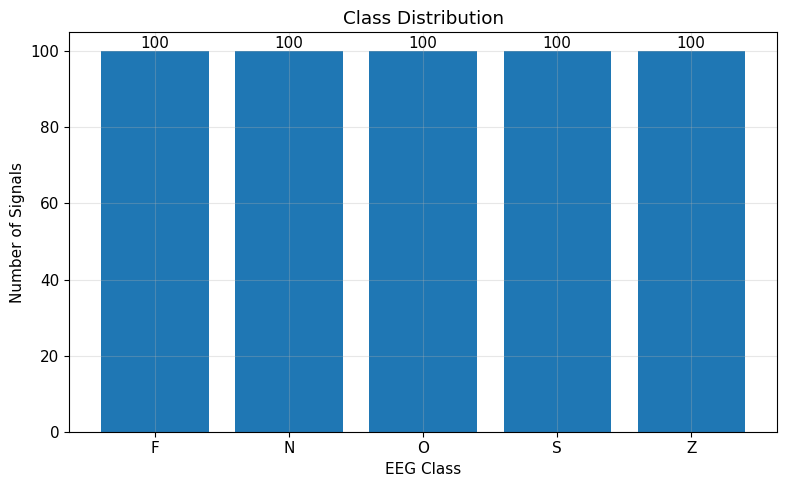

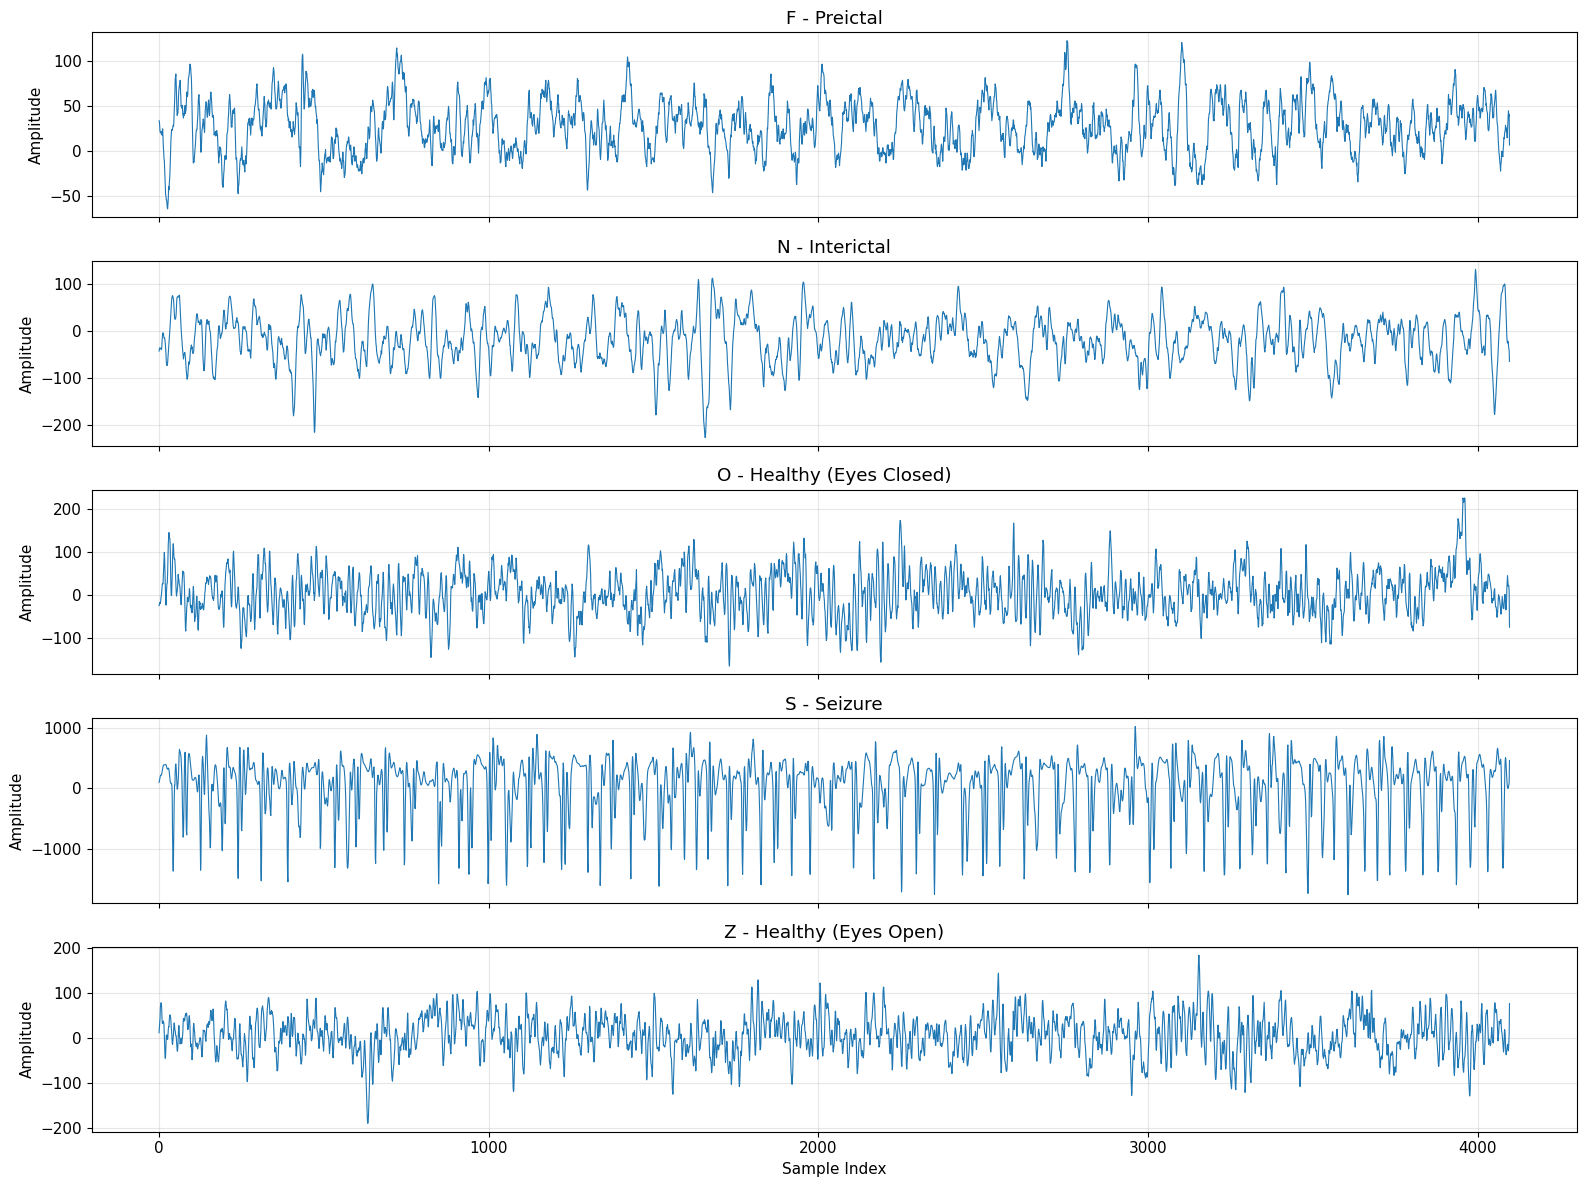

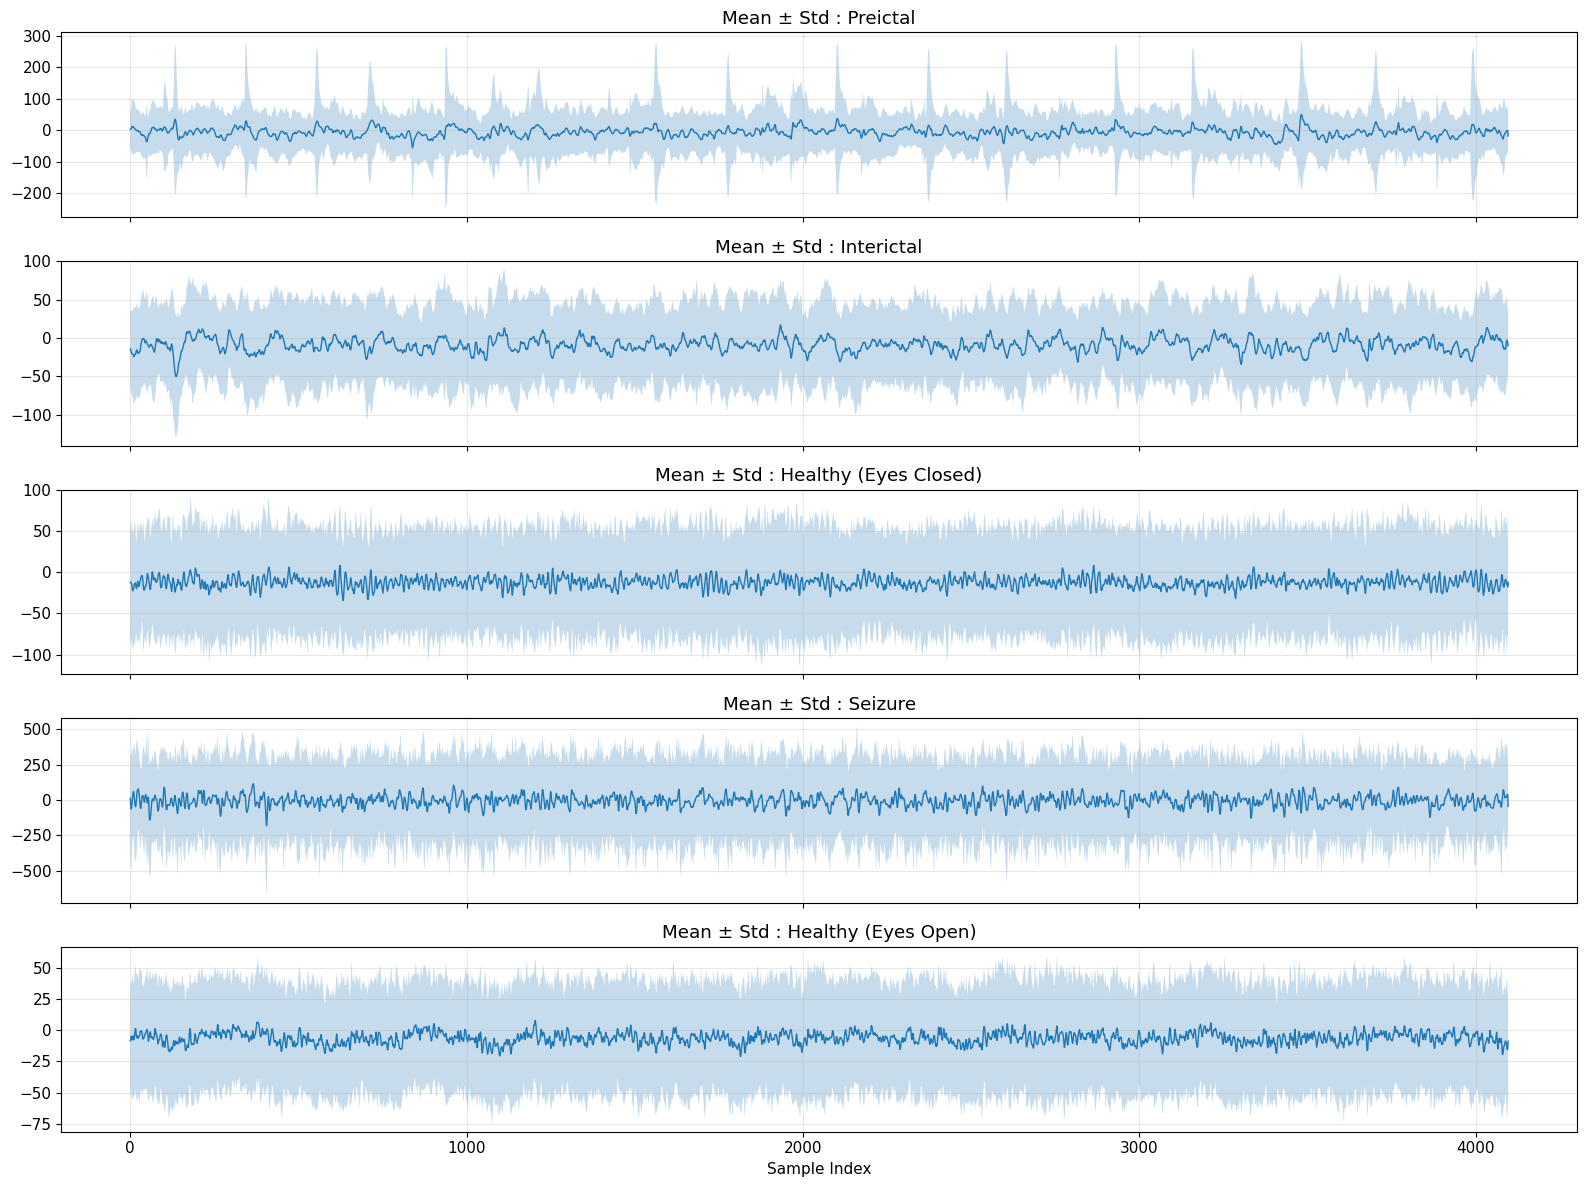

,count,mean,std,min,25%,50%,75%,max
mean,500.0,-7.721219,26.238781,-76.350256,-18.261960,-5.285087,6.058763,57.545277
std,500.0,104.968290,124.157784,18.606945,41.582288,53.833858,94.484524,612.550506
min,500.0,-354.538000,383.344773,-1885.000000,-322.500000,-212.000000,-158.750000,-46.000000
max,500.0,337.588000,375.545986,-25.000000,136.750000,193.000000,313.250000,2047.000000


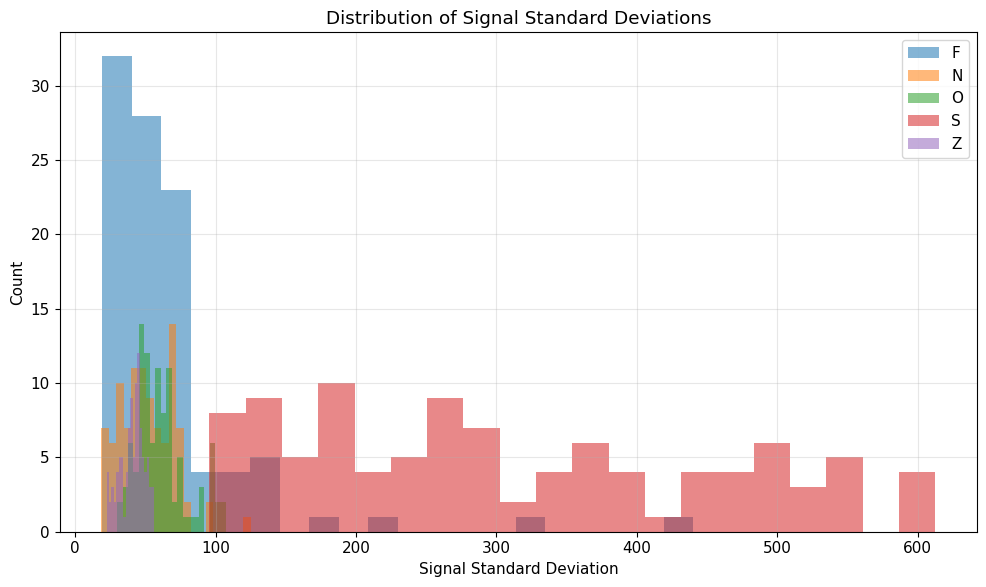

2026-07-19 10:39:00,486 | INFO | EDA Completed Successfully.



Saved Figures
class_distribution.png
example_signals.png
mean_signals.png
signal_std_distribution.png

Statistics Saved
/kaggle/working/NeuroAegis/reports/signal_statistics.csv


In [7]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 5 : Exploratory Data Analysis (EDA)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

logger.info("Starting Exploratory Data Analysis...")

PLOT_DIR = DIRS["plots"]

CLASS_DESCRIPTION = {
    "Z": "Healthy (Eyes Open)",
    "O": "Healthy (Eyes Closed)",
    "N": "Interictal",
    "F": "Preictal",
    "S": "Seizure"
}

# ------------------------------------------------------------
# Figure Style
# ------------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (12,6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

# ------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------

print("="*80)
print("DATASET SUMMARY")
print("="*80)

print(f"Total Signals        : {len(metadata)}")
print(f"Samples per Signal   : {signals.shape[1]}")
print(f"Sampling Frequency   : 173.61 Hz")
print(f"Signal Duration      : {signals.shape[1]/173.61:.2f} sec")

print("\nClass Distribution")

display(metadata["class"].value_counts().sort_index())

# ------------------------------------------------------------
# Class Distribution Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

counts = metadata["class"].value_counts().sort_index()

bars = plt.bar(
    counts.index,
    counts.values
)

plt.title("Class Distribution")
plt.xlabel("EEG Class")
plt.ylabel("Number of Signals")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        int(bar.get_height()),
        ha="center"
    )

plt.tight_layout()

plt.savefig(PLOT_DIR/"class_distribution.png",dpi=300)

plt.show()

# ------------------------------------------------------------
# Example Signal From Each Class
# ------------------------------------------------------------

fig, axes = plt.subplots(5,1,figsize=(16,12),sharex=True)

for i, cls in enumerate(sorted(metadata["class"].unique())):

    idx = metadata.index[
        metadata["class"]==cls
    ][0]

    axes[i].plot(
        signals[idx],
        linewidth=0.8
    )

    axes[i].set_title(
        f"{cls} - {CLASS_DESCRIPTION[cls]}"
    )

    axes[i].set_ylabel("Amplitude")

axes[-1].set_xlabel("Sample Index")

plt.tight_layout()

plt.savefig(
    PLOT_DIR/"example_signals.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Mean Signal Per Class
# ------------------------------------------------------------

fig, axes = plt.subplots(5,1,figsize=(16,12),sharex=True)

for i, cls in enumerate(sorted(metadata["class"].unique())):

    idx = metadata["class"]==cls

    mean_signal = signals[idx].mean(axis=0)

    std_signal = signals[idx].std(axis=0)

    axes[i].plot(
        mean_signal,
        linewidth=1
    )

    axes[i].fill_between(
        np.arange(len(mean_signal)),
        mean_signal-std_signal,
        mean_signal+std_signal,
        alpha=0.25
    )

    axes[i].set_title(
        f"Mean ± Std : {CLASS_DESCRIPTION[cls]}"
    )

axes[-1].set_xlabel("Sample Index")

plt.tight_layout()

plt.savefig(
    PLOT_DIR/"mean_signals.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Signal Statistics
# ------------------------------------------------------------

stats = metadata[
    ["mean","std","min","max"]
].describe().T

display(stats)

stats.to_csv(
    DIRS["reports"]/"signal_statistics.csv"
)

# ------------------------------------------------------------
# Signal Amplitude Histogram
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

for cls in sorted(metadata["class"].unique()):

    idx = metadata["class"]==cls

    plt.hist(
        metadata.loc[idx,"std"],
        bins=20,
        alpha=0.55,
        label=cls
    )

plt.legend()

plt.xlabel("Signal Standard Deviation")

plt.ylabel("Count")

plt.title("Distribution of Signal Standard Deviations")

plt.tight_layout()

plt.savefig(
    PLOT_DIR/"signal_std_distribution.png",
    dpi=300
)

plt.show()

logger.info("EDA Completed Successfully.")

print("\nSaved Figures")

for file in sorted(PLOT_DIR.glob("*.png")):
    print(file.name)

print("\nStatistics Saved")
print(DIRS["reports"]/"signal_statistics.csv")

2026-07-19 10:39:01,250 | INFO | Starting Frequency Domain Analysis...


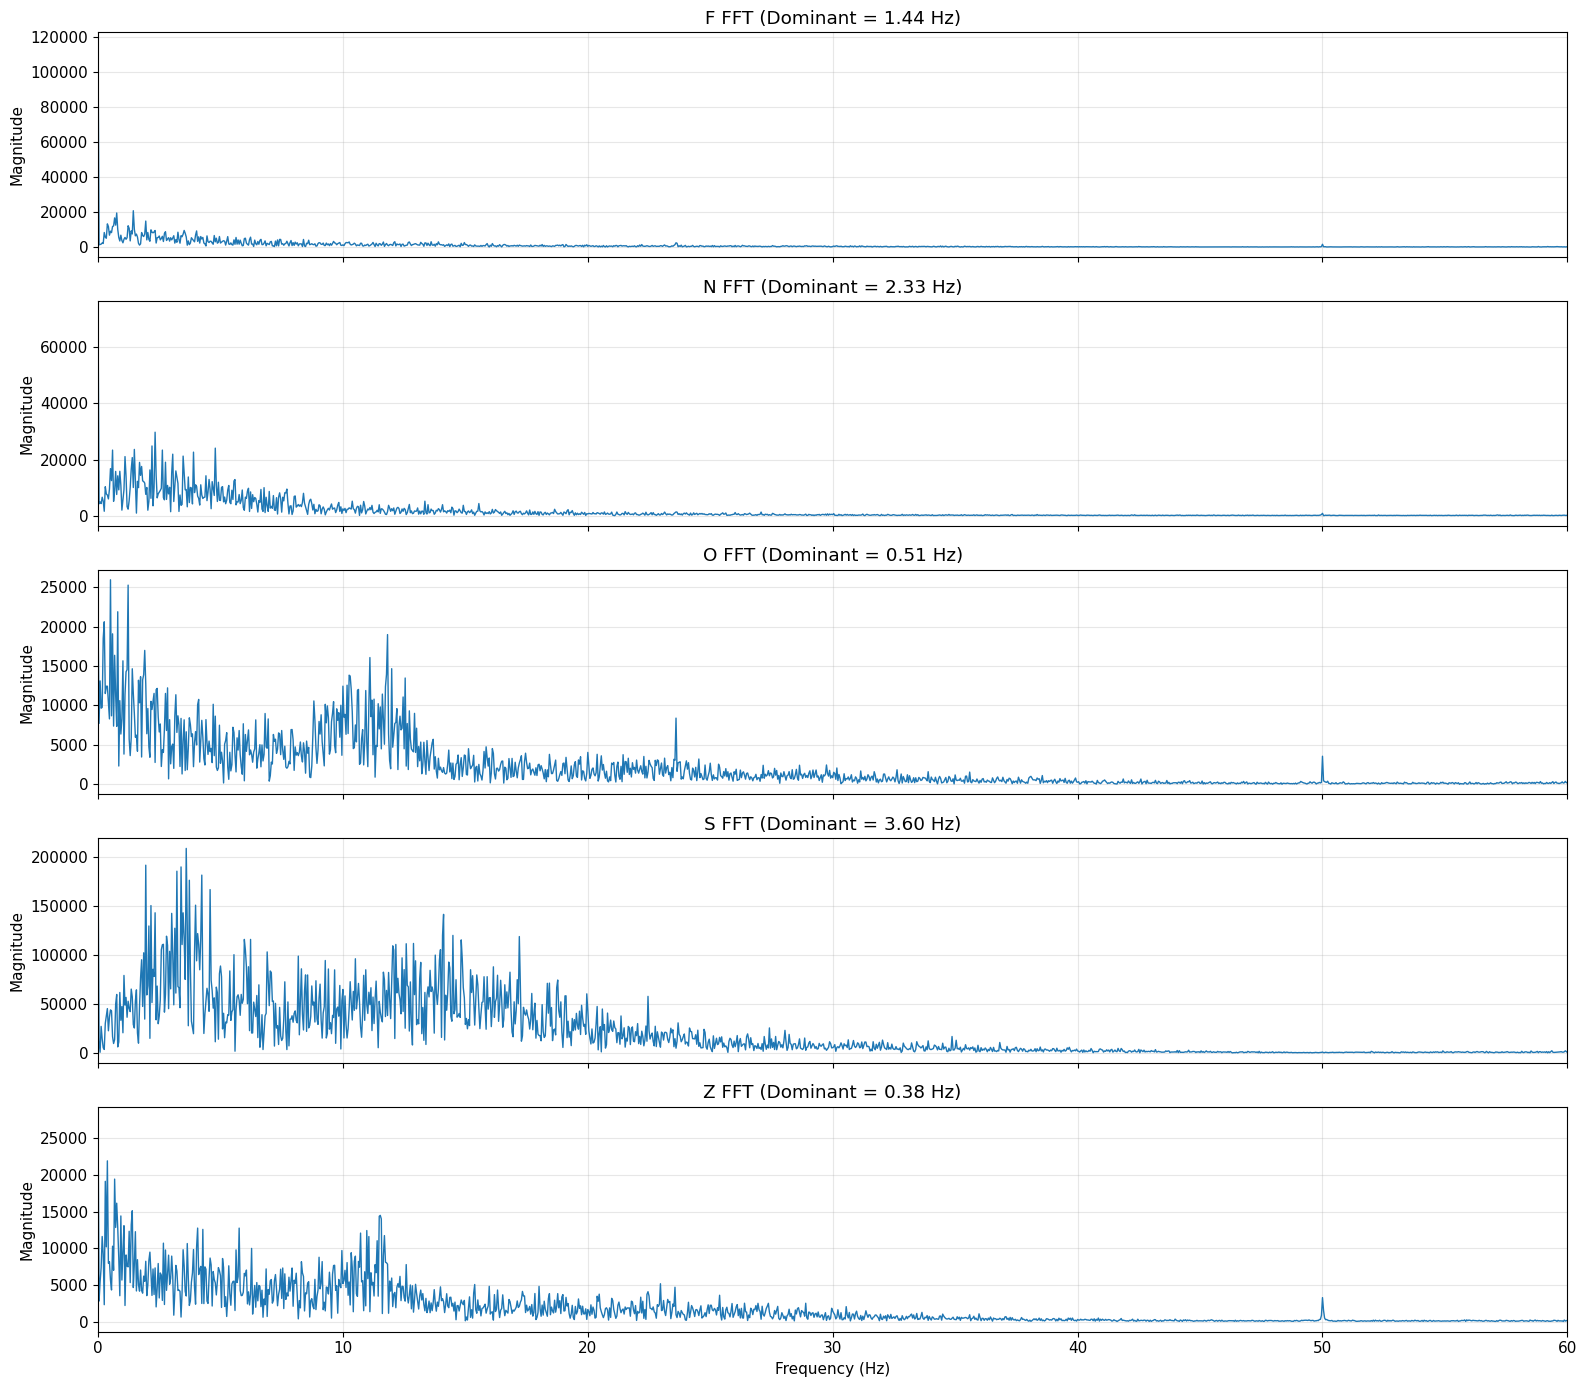

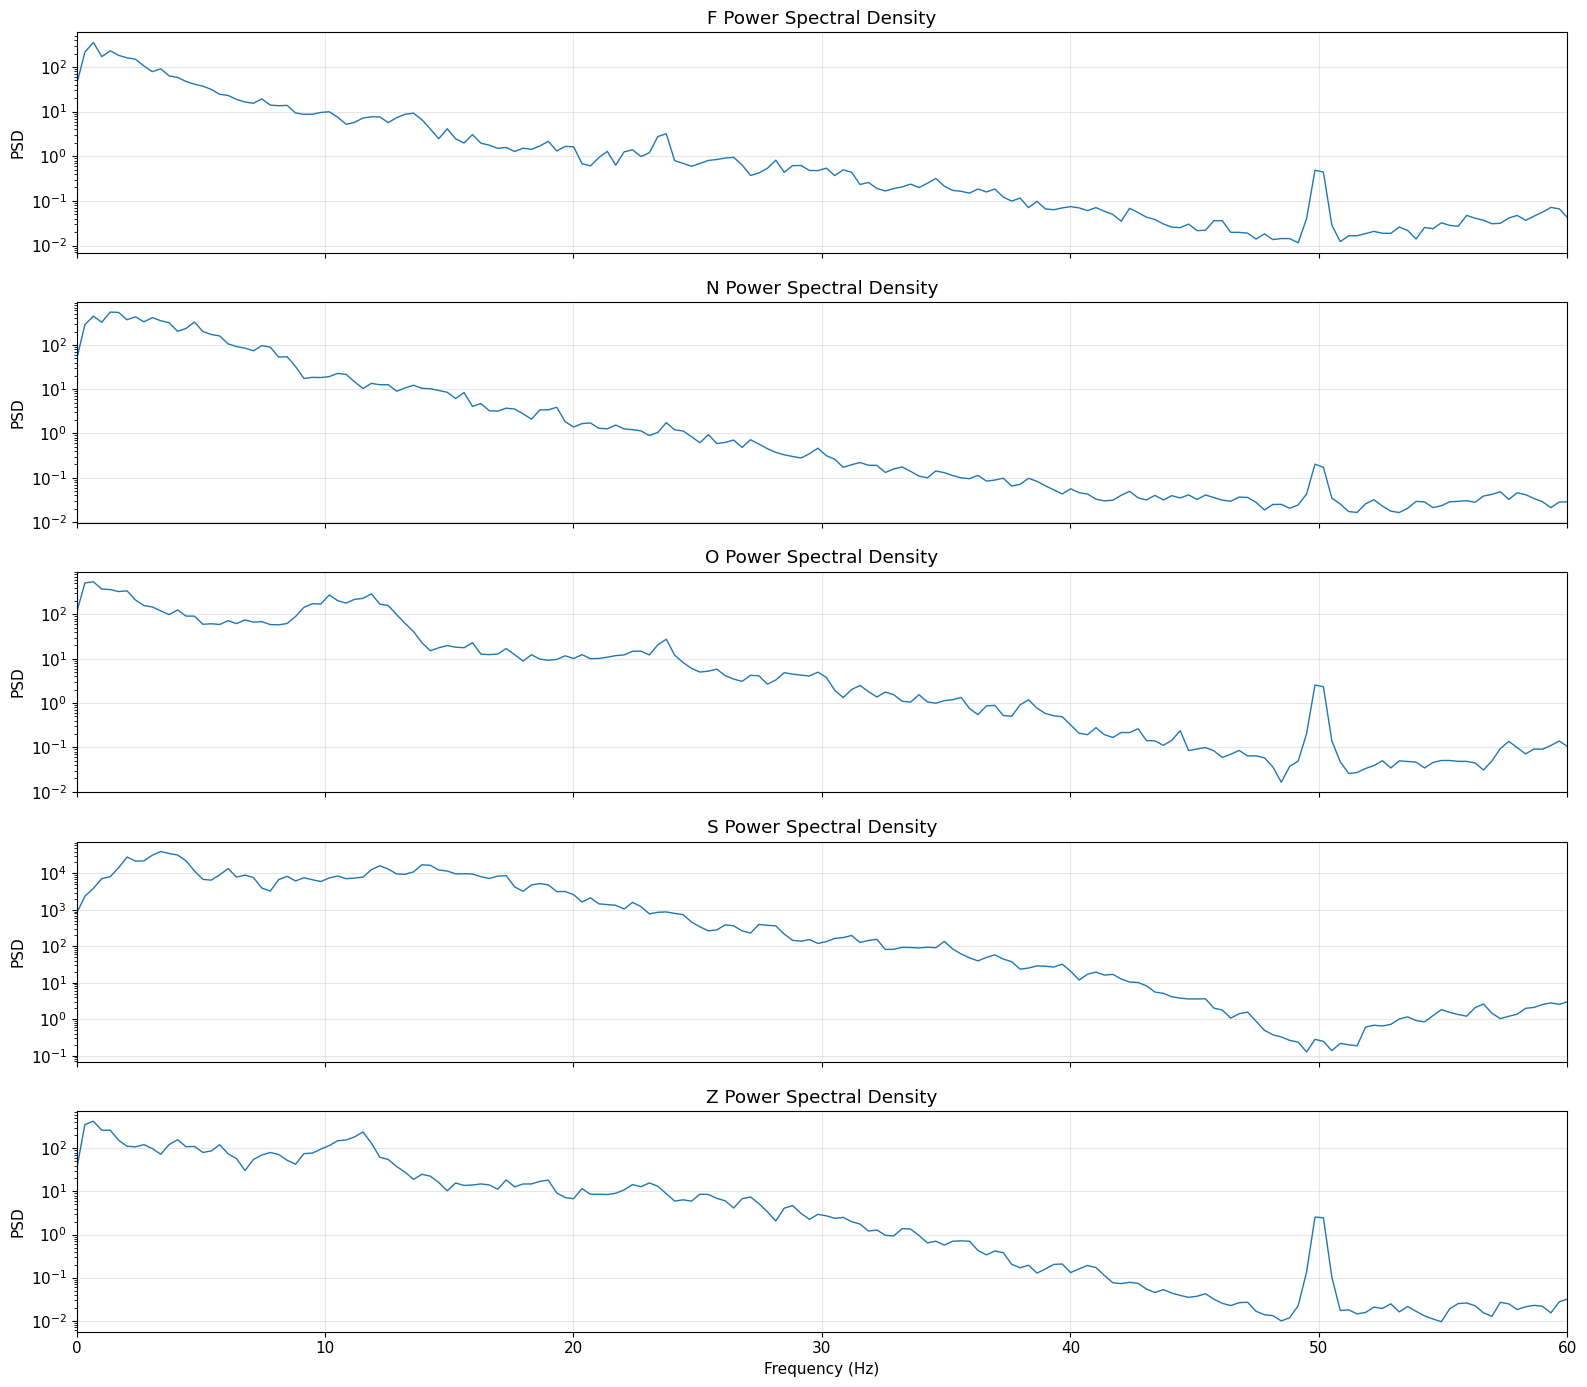

,class,dominant_frequency
0,F,1.440747
1,N,2.330620
2,O,0.508499
3,S,3.601867
4,Z,0.381374


2026-07-19 10:39:07,254 | INFO | Frequency Domain Analysis Completed.



Saved Figures
fft_comparison.png
psd_comparison.png

Saved Report
dominant_frequencies.csv


In [8]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 6 : Frequency Domain Analysis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

logger.info("Starting Frequency Domain Analysis...")

FS = 173.61

PLOT_DIR = DIRS["plots"]

classes = sorted(metadata["class"].unique())

# ------------------------------------------------------------
# FFT
# ------------------------------------------------------------

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

dominant_frequencies = []

for i, cls in enumerate(classes):

    idx = metadata.index[
        metadata["class"] == cls
    ][0]

    signal = signals[idx]

    fft = np.fft.rfft(signal)

    freqs = np.fft.rfftfreq(
        len(signal),
        d=1 / FS
    )

    magnitude = np.abs(fft)

    dominant_idx = np.argmax(magnitude[1:]) + 1

    dominant_freq = freqs[dominant_idx]

    dominant_frequencies.append({
        "class": cls,
        "dominant_frequency": dominant_freq
    })

    axes[i].plot(
        freqs,
        magnitude,
        linewidth=1
    )

    axes[i].set_xlim(0, 60)

    axes[i].set_title(
        f"{cls} FFT (Dominant = {dominant_freq:.2f} Hz)"
    )

    axes[i].set_ylabel("Magnitude")

axes[-1].set_xlabel("Frequency (Hz)")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "fft_comparison.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Power Spectral Density
# ------------------------------------------------------------

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

for i, cls in enumerate(classes):

    idx = metadata.index[
        metadata["class"] == cls
    ][0]

    signal = signals[idx]

    f, psd = welch(
        signal,
        fs=FS,
        nperseg=512
    )

    axes[i].semilogy(
        f,
        psd,
        linewidth=1
    )

    axes[i].set_xlim(0, 60)

    axes[i].set_title(
        f"{cls} Power Spectral Density"
    )

    axes[i].set_ylabel("PSD")

axes[-1].set_xlabel("Frequency (Hz)")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "psd_comparison.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Dominant Frequencies
# ------------------------------------------------------------

dominant_df = pd.DataFrame(
    dominant_frequencies
)

display(dominant_df)

dominant_df.to_csv(
    DIRS["reports"] / "dominant_frequencies.csv",
    index=False
)

logger.info("Frequency Domain Analysis Completed.")

print("\nSaved Figures")

print("fft_comparison.png")
print("psd_comparison.png")

print("\nSaved Report")

print("dominant_frequencies.csv")

2026-07-19 10:39:07,350 | INFO | Starting Wavelet Benchmark...


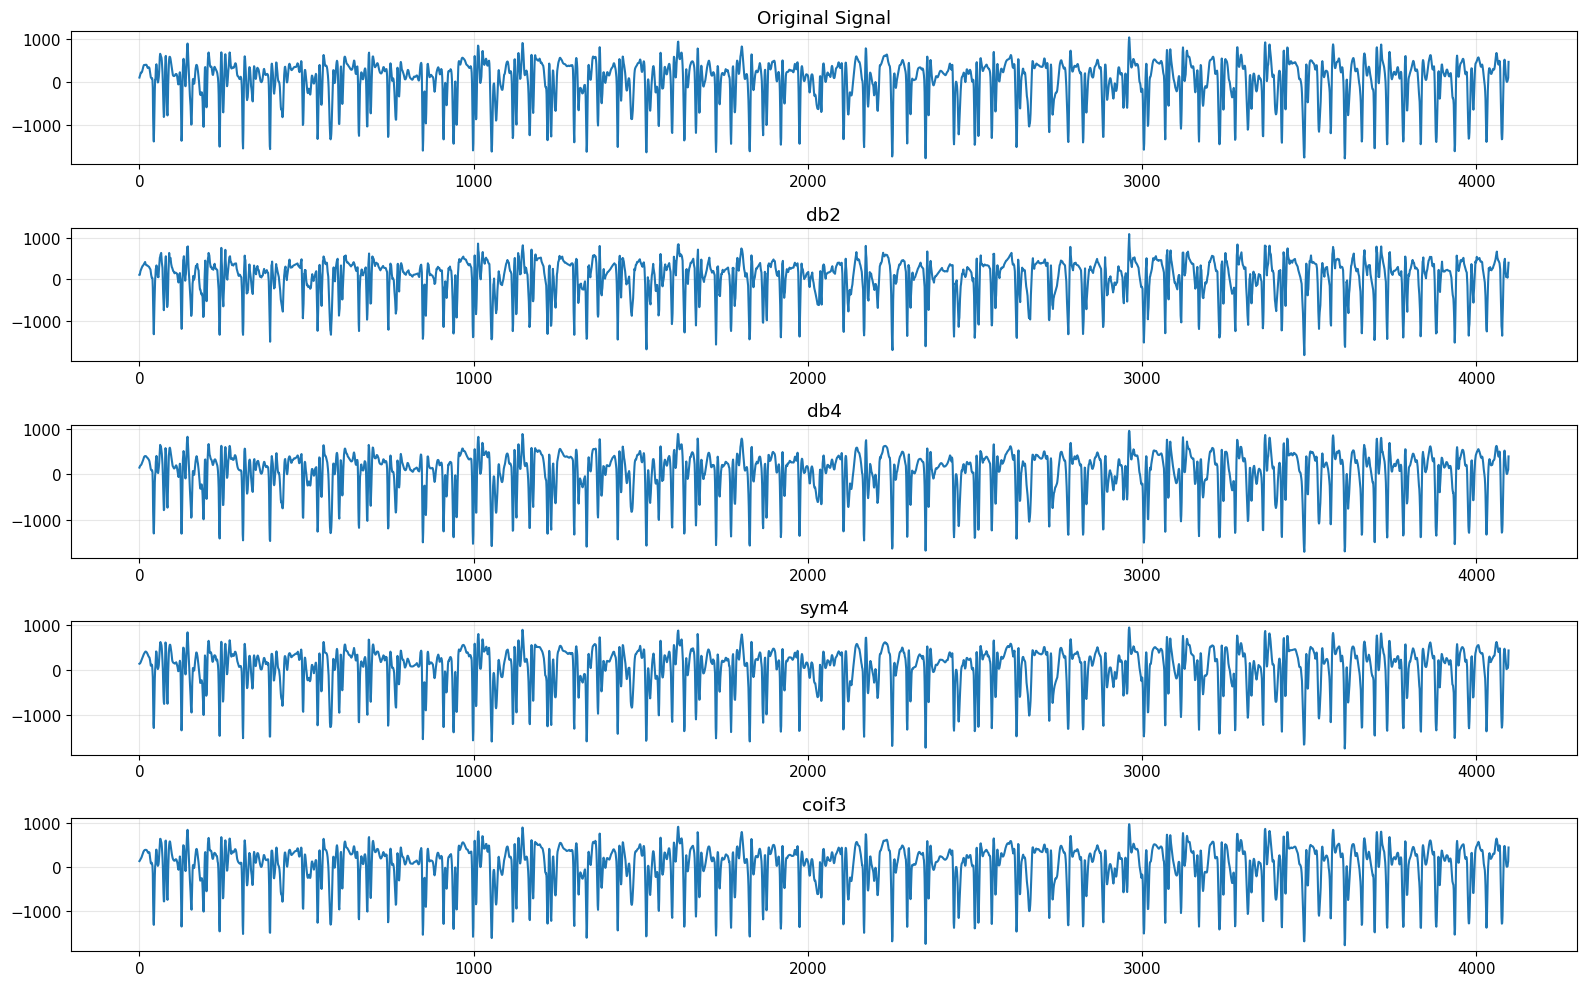

,Wavelet,RMSE,Energy Retained,Runtime (sec)
0,db2,62.381791,0.884715,0.004028
1,db4,25.577261,0.954755,0.000431
2,sym4,26.622812,0.952825,0.000391
3,coif3,19.012167,0.968554,0.000489


2026-07-19 10:39:09,452 | INFO | Wavelet Benchmark Completed



Saved
wavelet_comparison.png
wavelet_benchmark.csv


In [9]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 7 : Wavelet Benchmark & Selection
# ============================================================

import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

logger.info("Starting Wavelet Benchmark...")

# ------------------------------------------------------------
# Candidate Wavelets
# ------------------------------------------------------------

WAVELETS = [
    "db2",
    "db4",
    "sym4",
    "coif3"
]

LEVEL = 4

# Use one seizure sample as benchmark
sample_idx = metadata.index[
    metadata["class"]=="S"
][0]

raw_signal = signals[sample_idx]

results = []

plt.figure(figsize=(16,10))

plt.subplot(len(WAVELETS)+1,1,1)
plt.plot(raw_signal)
plt.title("Original Signal")

for i,wavelet in enumerate(WAVELETS):

    start = time.time()

    coeffs = pywt.wavedec(
        raw_signal,
        wavelet,
        level=LEVEL
    )

    sigma = np.median(
        np.abs(coeffs[-1])
    ) / 0.6745

    threshold = sigma * np.sqrt(
        2*np.log(len(raw_signal))
    )

    coeffs_denoised = [
        coeffs[0]
    ]

    for c in coeffs[1:]:

        coeffs_denoised.append(
            pywt.threshold(
                c,
                threshold,
                mode="soft"
            )
        )

    denoised = pywt.waverec(
        coeffs_denoised,
        wavelet
    )

    denoised = denoised[:len(raw_signal)]

    runtime = time.time()-start

    rmse = np.sqrt(
        np.mean(
            (raw_signal-denoised)**2
        )
    )

    energy_retained = (
        np.sum(denoised**2)
        /
        np.sum(raw_signal**2)
    )

    results.append({

        "Wavelet":wavelet,

        "RMSE":rmse,

        "Energy Retained":energy_retained,

        "Runtime (sec)":runtime

    })

    plt.subplot(len(WAVELETS)+1,1,i+2)

    plt.plot(denoised)

    plt.title(
        f"{wavelet}"
    )

plt.tight_layout()

plt.savefig(
    PLOT_DIR/"wavelet_comparison.png",
    dpi=300
)

plt.show()

results = pd.DataFrame(results)

display(results)

results.to_csv(
    DIRS["reports"]/"wavelet_benchmark.csv",
    index=False
)

logger.info("Wavelet Benchmark Completed")

print("\nSaved")

print("wavelet_comparison.png")

print("wavelet_benchmark.csv")

2026-07-19 10:39:09,466 | INFO | Generating Denoised Dataset...


Generating Denoised Dataset
Wavelet : coif3
Level   : 4


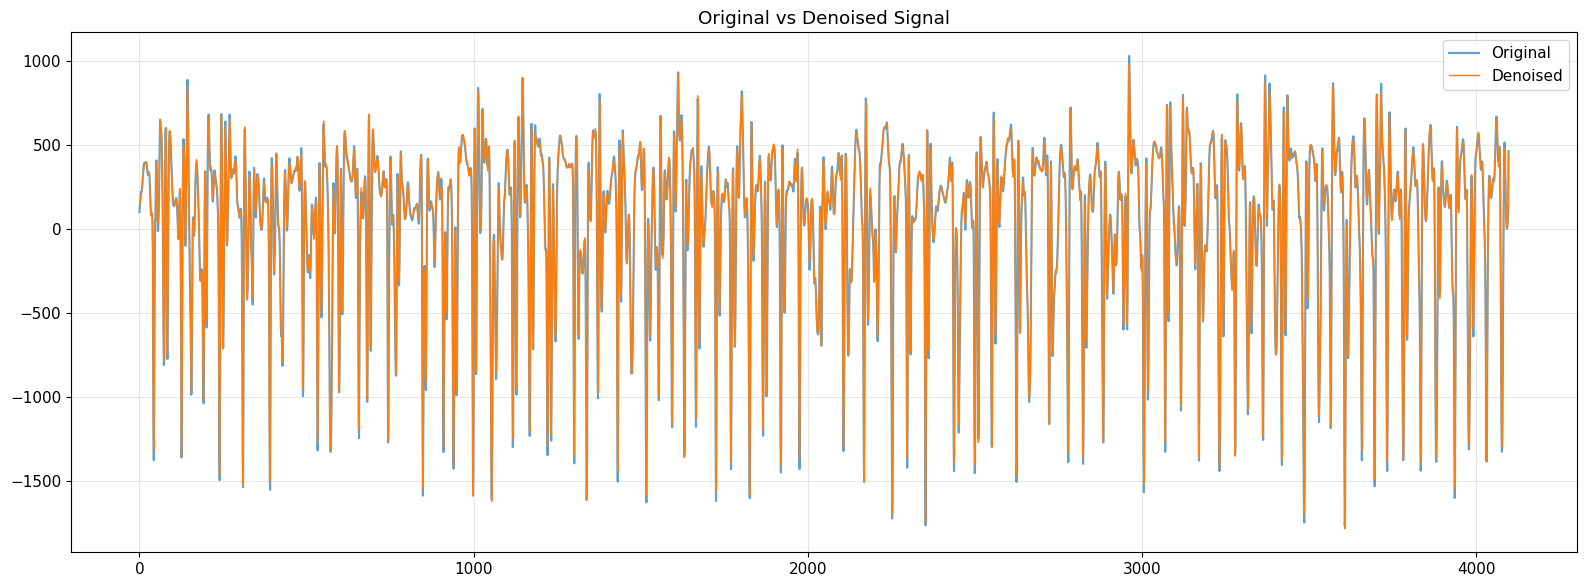

2026-07-19 10:39:11,342 | INFO | Denoised Dataset Saved : /kaggle/working/NeuroAegis/features/coif3_denoised_dataset.npz
2026-07-19 10:39:11,343 | INFO | Execution Time : 1.87 sec



Dataset Shape
(500, 4097)

Saved
/kaggle/working/NeuroAegis/features/coif3_denoised_dataset.npz

Execution Time : 1.87 sec


15862

In [10]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 8 : Generate Denoised Dataset
# ============================================================

import gc
import time
import pywt
import numpy as np
import matplotlib.pyplot as plt

logger.info("Generating Denoised Dataset...")

START = time.time()

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SELECTED_WAVELET = "coif3"
LEVEL = 4

print("=" * 80)
print("Generating Denoised Dataset")
print("=" * 80)

print(f"Wavelet : {SELECTED_WAVELET}")
print(f"Level   : {LEVEL}")

# ------------------------------------------------------------
# Denoising Function
# ------------------------------------------------------------

def wavelet_denoise(signal,
                    wavelet="coif3",
                    level=4):

    coeffs = pywt.wavedec(
        signal,
        wavelet,
        level=level
    )

    sigma = np.median(
        np.abs(coeffs[-1])
    ) / 0.6745

    threshold = sigma * np.sqrt(
        2 * np.log(len(signal))
    )

    coeffs_denoised = [coeffs[0]]

    for c in coeffs[1:]:

        coeffs_denoised.append(
            pywt.threshold(
                c,
                threshold,
                mode="soft"
            )
        )

    reconstructed = pywt.waverec(
        coeffs_denoised,
        wavelet
    )

    return reconstructed[:len(signal)]

# ------------------------------------------------------------
# Denoise Entire Dataset
# ------------------------------------------------------------

denoised_signals = np.empty_like(signals)

for i in range(len(signals)):

    denoised_signals[i] = wavelet_denoise(
        signals[i],
        wavelet=SELECTED_WAVELET,
        level=LEVEL
    )

# ------------------------------------------------------------
# Save Dataset
# ------------------------------------------------------------

save_path = DIRS["features"] / "coif3_denoised_dataset.npz"

np.savez_compressed(
    save_path,
    signals=denoised_signals,
    labels=metadata["label"].values,
    binary_labels=metadata["binary_label"].values
)

# ------------------------------------------------------------
# Compare One Example
# ------------------------------------------------------------

sample_idx = metadata.index[
    metadata["class"] == "S"
][0]

plt.figure(figsize=(16,6))

plt.plot(
    signals[sample_idx],
    label="Original",
    alpha=0.7
)

plt.plot(
    denoised_signals[sample_idx],
    label="Denoised",
    linewidth=1
)

plt.legend()

plt.title(
    "Original vs Denoised Signal"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "original_vs_denoised.png",
    dpi=300
)

plt.show()

END = time.time()

print("\nDataset Shape")
print(denoised_signals.shape)

print("\nSaved")
print(save_path)

print(f"\nExecution Time : {END-START:.2f} sec")

logger.info(f"Denoised Dataset Saved : {save_path}")
logger.info(f"Execution Time : {END-START:.2f} sec")

# ------------------------------------------------------------
# Memory Cleanup
# ------------------------------------------------------------

gc.collect()

In [11]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 9 : Feature Extraction Library
# ============================================================

import numpy as np
import pandas as pd
import pywt

from scipy.stats import (
    skew,
    kurtosis,
    entropy,
    iqr
)

from scipy.signal import welch

logger.info("Initializing NeuroAegis Feature Extraction Library...")

FS = 173.61

# ============================================================
# Hjorth Parameters
# ============================================================

def hjorth_parameters(signal):

    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)

    activity = np.var(signal)

    mobility = np.sqrt(
        np.var(first_deriv) /
        (activity + 1e-12)
    )

    complexity = np.sqrt(
        np.var(second_deriv) /
        (np.var(first_deriv) + 1e-12)
    ) / (mobility + 1e-12)

    return activity, mobility, complexity


# ============================================================
# Zero Crossing Rate
# ============================================================

def zero_crossing_rate(signal):

    return np.sum(
        np.diff(
            np.sign(signal)
        ) != 0
    )


# ============================================================
# Line Length
# ============================================================

def line_length(signal):

    return np.sum(
        np.abs(
            np.diff(signal)
        )
    )


# ============================================================
# Band Power
# ============================================================

def bandpower(freqs, psd, low, high):

    idx = np.logical_and(
        freqs >= low,
        freqs <= high
    )

    return np.trapz(
        psd[idx],
        freqs[idx]
    )


# ============================================================
# Frequency Features
# ============================================================

def frequency_features(signal):

    freqs, psd = welch(
        signal,
        fs=FS,
        nperseg=512
    )

    total_power = np.trapz(psd, freqs)

    delta = bandpower(freqs, psd, 0.5, 4)
    theta = bandpower(freqs, psd, 4, 8)
    alpha = bandpower(freqs, psd, 8, 13)
    beta = bandpower(freqs, psd, 13, 30)
    gamma = bandpower(freqs, psd, 30, 45)

    dominant_freq = freqs[
        np.argmax(psd)
    ]

    spectral_entropy = entropy(
        psd / np.sum(psd)
    )

    spectral_centroid = np.sum(
        freqs * psd
    ) / (np.sum(psd) + 1e-12)

    return {

        "delta_power": delta,

        "theta_power": theta,

        "alpha_power": alpha,

        "beta_power": beta,

        "gamma_power": gamma,

        "dominant_frequency": dominant_freq,

        "spectral_entropy": spectral_entropy,

        "spectral_centroid": spectral_centroid,

        "total_power": total_power
    }


# ============================================================
# Wavelet Features
# ============================================================

def wavelet_features(signal):

    coeffs = pywt.wavedec(
        signal,
        wavelet="coif3",
        level=4
    )

    features = {}

    for i, coeff in enumerate(coeffs):

        energy = np.sum(coeff**2)

        features[f"wavelet_energy_{i}"] = energy

        features[f"wavelet_mean_{i}"] = np.mean(coeff)

        features[f"wavelet_std_{i}"] = np.std(coeff)

    return features


# ============================================================
# Time Features
# ============================================================

def time_features(signal):

    rms = np.sqrt(
        np.mean(signal**2)
    )

    activity, mobility, complexity = hjorth_parameters(signal)

    return {

        "mean": np.mean(signal),

        "median": np.median(signal),

        "std": np.std(signal),

        "variance": np.var(signal),

        "minimum": np.min(signal),

        "maximum": np.max(signal),

        "range": np.ptp(signal),

        "rms": rms,

        "energy": np.sum(signal**2),

        "absolute_mean": np.mean(np.abs(signal)),

        "line_length": line_length(signal),

        "zero_crossings": zero_crossing_rate(signal),

        "skewness": skew(signal),

        "kurtosis": kurtosis(signal),

        "iqr": iqr(signal),

        "hjorth_activity": activity,

        "hjorth_mobility": mobility,

        "hjorth_complexity": complexity
    }


# ============================================================
# Master Feature Function
# ============================================================

def extract_features(signal):

    features = {}

    features.update(
        time_features(signal)
    )

    features.update(
        frequency_features(signal)
    )

    features.update(
        wavelet_features(signal)
    )

    return features


logger.info("Feature Extraction Library Ready.")

print("="*70)
print("Feature Extraction Library Loaded Successfully")
print("="*70)

print("Functions Available")

print("✓ time_features()")
print("✓ frequency_features()")
print("✓ wavelet_features()")
print("✓ hjorth_parameters()")
print("✓ extract_features()")

2026-07-19 10:39:11,523 | INFO | Initializing NeuroAegis Feature Extraction Library...
2026-07-19 10:39:11,527 | INFO | Feature Extraction Library Ready.


Feature Extraction Library Loaded Successfully
Functions Available
✓ time_features()
✓ frequency_features()
✓ wavelet_features()
✓ hjorth_parameters()
✓ extract_features()


In [12]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 10 : Validate Feature Extraction
# ============================================================

import numpy as np
import pandas as pd

logger.info("Validating Feature Extraction...")

print("=" * 80)
print("Feature Extraction Validation")
print("=" * 80)

# ------------------------------------------------------------
# Select one seizure sample
# ------------------------------------------------------------

sample_idx = metadata.index[
    metadata["class"] == "S"
][0]

sample_signal = denoised_signals[sample_idx]

print(f"Sample Index : {sample_idx}")
print(f"Class        : {metadata.loc[sample_idx,'class']}")
print(f"File         : {metadata.loc[sample_idx,'file']}")

# ------------------------------------------------------------
# Extract Features
# ------------------------------------------------------------

feature_dict = extract_features(sample_signal)

feature_df = pd.DataFrame(
    feature_dict.items(),
    columns=["Feature", "Value"]
)

print("\nTotal Features Extracted :", len(feature_df))

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

nan_count = feature_df["Value"].isna().sum()

inf_count = np.isinf(feature_df["Value"]).sum()

duplicate_count = feature_df["Feature"].duplicated().sum()

print("\nValidation Summary")
print("-"*40)

print(f"NaN Values        : {nan_count}")
print(f"Infinite Values   : {inf_count}")
print(f"Duplicate Features: {duplicate_count}")

assert nan_count == 0, "NaN values detected!"
assert inf_count == 0, "Infinite values detected!"
assert duplicate_count == 0, "Duplicate feature names detected!"

print("\nFeature Categories")

time_features_count = 18
freq_features_count = 9
wavelet_features_count = len(feature_df) - time_features_count - freq_features_count

print(f"Time Features      : {time_features_count}")
print(f"Frequency Features : {freq_features_count}")
print(f"Wavelet Features   : {wavelet_features_count}")

print("\nFeature Statistics")
print("-"*40)

print(f"Minimum Value : {feature_df['Value'].min():.4f}")
print(f"Maximum Value : {feature_df['Value'].max():.4f}")

display(feature_df)

logger.info(f"Feature Validation Completed.")
logger.info(f"Total Features : {len(feature_df)}")

print("\n✓ Feature extraction validation passed successfully.")

2026-07-19 10:39:11,546 | INFO | Validating Feature Extraction...


Feature Extraction Validation
Sample Index : 300
Class        : S
File         : S001.txt

Total Features Extracted : 42

Validation Summary
----------------------------------------
NaN Values        : 0
Infinite Values   : 0
Duplicate Features: 0

Feature Categories
Time Features      : 18
Frequency Features : 9
Wavelet Features   : 15

Feature Statistics
----------------------------------------
Minimum Value : -1780.7812
Maximum Value : 917305856.0000


,Feature,Value
0,mean,4.710577e+01
1,median,1.857288e+02
2,std,4.708269e+02
3,variance,2.216780e+05
4,minimum,-1.780781e+03
5,maximum,9.735308e+02
6,range,2.754312e+03
7,rms,4.731775e+02
8,energy,9.173059e+08
9,absolute_mean,3.724872e+02


2026-07-19 10:39:11,564 | INFO | Feature Validation Completed.
2026-07-19 10:39:11,565 | INFO | Total Features : 42



✓ Feature extraction validation passed successfully.


In [13]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 10.5 : Upgrade Feature Library
# ============================================================

from scipy.stats import gmean

logger.info("Upgrading Feature Extraction Library...")

# ============================================================
# Improved Frequency Features
# ============================================================

def frequency_features(signal):

    freqs, psd = welch(
        signal,
        fs=FS,
        nperseg=512
    )

    total_power = np.trapz(psd, freqs) + 1e-12

    delta = bandpower(freqs, psd, 0.5, 4)
    theta = bandpower(freqs, psd, 4, 8)
    alpha = bandpower(freqs, psd, 8, 13)
    beta = bandpower(freqs, psd, 13, 30)
    gamma = bandpower(freqs, psd, 30, 45)

    dominant_frequency = freqs[np.argmax(psd)]

    spectral_entropy = entropy(psd / np.sum(psd))

    spectral_centroid = np.sum(
        freqs * psd
    ) / np.sum(psd)

    return {

        "delta_power": delta,
        "theta_power": theta,
        "alpha_power": alpha,
        "beta_power": beta,
        "gamma_power": gamma,

        "relative_delta": delta / total_power,
        "relative_theta": theta / total_power,
        "relative_alpha": alpha / total_power,
        "relative_beta": beta / total_power,
        "relative_gamma": gamma / total_power,

        "dominant_frequency": dominant_frequency,

        "spectral_entropy": spectral_entropy,

        "spectral_centroid": spectral_centroid,

        "total_power": total_power
    }


# ============================================================
# Improved Wavelet Features
# ============================================================

def wavelet_features(signal):

    coeffs = pywt.wavedec(
        signal,
        "coif3",
        level=4
    )

    energies = [
        np.sum(c**2)
        for c in coeffs
    ]

    total_energy = np.sum(energies) + 1e-12

    probs = np.array(energies) / total_energy

    features = {}

    wavelet_entropy = entropy(probs)

    features["wavelet_entropy"] = wavelet_entropy

    for i, c in enumerate(coeffs):

        features[f"wavelet_energy_{i}"] = energies[i]

        features[f"wavelet_relative_energy_{i}"] = (
            energies[i] / total_energy
        )

        features[f"wavelet_mean_{i}"] = np.mean(c)

        features[f"wavelet_std_{i}"] = np.std(c)

    return features


# ============================================================
# Improved Time Features
# ============================================================

def time_features(signal):

    rms = np.sqrt(np.mean(signal**2))

    abs_mean = np.mean(np.abs(signal))

    peak = np.max(np.abs(signal))

    activity, mobility, complexity = hjorth_parameters(signal)

    crest_factor = peak / (rms + 1e-12)

    shape_factor = rms / (abs_mean + 1e-12)

    impulse_factor = peak / (abs_mean + 1e-12)

    clearance_factor = peak / (
        (np.mean(np.sqrt(np.abs(signal)))**2) + 1e-12
    )

    return {

        "mean": np.mean(signal),
        "median": np.median(signal),
        "std": np.std(signal),
        "variance": np.var(signal),

        "minimum": np.min(signal),
        "maximum": np.max(signal),
        "range": np.ptp(signal),

        "rms": rms,

        "energy": np.sum(signal**2),

        "absolute_mean": abs_mean,

        "line_length": line_length(signal),

        "zero_crossings": zero_crossing_rate(signal),

        "skewness": skew(signal),

        "kurtosis": kurtosis(signal),

        "iqr": iqr(signal),

        "crest_factor": crest_factor,
        "shape_factor": shape_factor,
        "impulse_factor": impulse_factor,
        "clearance_factor": clearance_factor,

        "hjorth_activity": activity,
        "hjorth_mobility": mobility,
        "hjorth_complexity": complexity
    }


# ============================================================
# Updated Master Function
# ============================================================

def extract_features(signal):

    features = {}

    features.update(
        time_features(signal)
    )

    features.update(
        frequency_features(signal)
    )

    features.update(
        wavelet_features(signal)
    )

    return features

logger.info("Feature Library Upgraded Successfully.")

print("="*70)
print("Feature Library Successfully Upgraded")
print("="*70)

print("\nNew Features Added")

print("✓ Relative Band Powers")
print("✓ Wavelet Entropy")
print("✓ Relative Wavelet Energy")
print("✓ Crest Factor")
print("✓ Shape Factor")
print("✓ Impulse Factor")
print("✓ Clearance Factor")

2026-07-19 10:39:11,581 | INFO | Upgrading Feature Extraction Library...
2026-07-19 10:39:11,583 | INFO | Feature Library Upgraded Successfully.


Feature Library Successfully Upgraded

New Features Added
✓ Relative Band Powers
✓ Wavelet Entropy
✓ Relative Wavelet Energy
✓ Crest Factor
✓ Shape Factor
✓ Impulse Factor
✓ Clearance Factor


In [14]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 11 : Generate Complete Feature Matrix
# ============================================================

import json
import time
import gc
import numpy as np
import pandas as pd

logger.info("Generating Complete Feature Matrix...")

START = time.time()

print("=" * 80)
print("Generating Complete Feature Matrix")
print("=" * 80)

feature_rows = []

total_samples = len(denoised_signals)

for idx, signal in enumerate(denoised_signals):

    features = extract_features(signal)

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    features["file"] = metadata.loc[idx, "file"]
    features["class"] = metadata.loc[idx, "class"]
    features["label"] = metadata.loc[idx, "label"]
    features["label_name"] = metadata.loc[idx, "label_name"]
    features["binary_label"] = metadata.loc[idx, "binary_label"]

    feature_rows.append(features)

    if (idx + 1) % 50 == 0 or (idx + 1) == total_samples:
        print(f"Processed {idx+1}/{total_samples}")

# ------------------------------------------------------------
# DataFrame
# ------------------------------------------------------------

features_df = pd.DataFrame(feature_rows)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

nan_total = features_df.isna().sum().sum()

inf_total = np.isinf(
    features_df.select_dtypes(include=[np.number])
).sum().sum()

print("\nValidation")
print("-" * 40)

print(f"Shape          : {features_df.shape}")
print(f"NaN Values     : {nan_total}")
print(f"Infinite Values: {inf_total}")

assert nan_total == 0, "NaN values detected!"
assert inf_total == 0, "Infinite values detected!"

# ------------------------------------------------------------
# Save Feature Names
# ------------------------------------------------------------

feature_columns = [
    c for c in features_df.columns
    if c not in [
        "file",
        "class",
        "label",
        "label_name",
        "binary_label"
    ]
]

with open(
    DIRS["features"] / "feature_names.json",
    "w"
) as f:

    json.dump(feature_columns, f, indent=4)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

csv_path = DIRS["features"] / "features.csv"

features_df.to_csv(
    csv_path,
    index=False
)

# ------------------------------------------------------------
# Save Parquet
# ------------------------------------------------------------

parquet_path = DIRS["features"] / "features.parquet"

features_df.to_parquet(
    parquet_path,
    index=False
)

# ------------------------------------------------------------
# Save NumPy Matrix
# ------------------------------------------------------------

X = features_df[feature_columns].values.astype(np.float32)

y = features_df["label"].values.astype(np.int64)

np.savez_compressed(
    DIRS["features"] / "feature_matrix.npz",
    X=X,
    y=y
)

END = time.time()

print("\nSaved Files")
print("-" * 40)

print(csv_path)
print(parquet_path)
print(DIRS["features"] / "feature_matrix.npz")
print(DIRS["features"] / "feature_names.json")

print("\nSummary")
print("-" * 40)

print(f"Samples        : {len(features_df)}")
print(f"Total Features : {len(feature_columns)}")
print(f"Classes        : {features_df['class'].nunique()}")
print(f"Execution Time : {END-START:.2f} sec")

logger.info(f"Feature Matrix Shape : {features_df.shape}")
logger.info(f"Feature Count : {len(feature_columns)}")
logger.info(f"Execution Time : {END-START:.2f} sec")

display(features_df.head())

gc.collect()

2026-07-19 10:39:11,604 | INFO | Generating Complete Feature Matrix...


Generating Complete Feature Matrix
Processed 50/500
Processed 100/500
Processed 150/500
Processed 200/500
Processed 250/500
Processed 300/500
Processed 350/500
Processed 400/500
Processed 450/500
Processed 500/500

Validation
----------------------------------------
Shape          : (500, 62)
NaN Values     : 0
Infinite Values: 0


2026-07-19 10:39:14,153 | INFO | Feature Matrix Shape : (500, 62)
2026-07-19 10:39:14,154 | INFO | Feature Count : 57
2026-07-19 10:39:14,155 | INFO | Execution Time : 2.55 sec



Saved Files
----------------------------------------
/kaggle/working/NeuroAegis/features/features.csv
/kaggle/working/NeuroAegis/features/features.parquet
/kaggle/working/NeuroAegis/features/feature_matrix.npz
/kaggle/working/NeuroAegis/features/feature_names.json

Summary
----------------------------------------
Samples        : 500
Total Features : 57
Classes        : 5
Execution Time : 2.55 sec


,mean,median,std,variance,minimum,maximum,range,rms,energy,absolute_mean,...,wavelet_std_3,wavelet_energy_4,wavelet_relative_energy_4,wavelet_mean_4,wavelet_std_4,file,class,label,label_name,binary_label
0,28.567820,29.345272,27.454269,753.736938,-62.787064,119.744347,182.531403,39.621422,6431705.0,32.512478,...,1.650548,103.560471,0.000016,-0.000106,0.224378,F001.txt,F,3,Preictal,0
1,31.781525,27.516470,132.944534,17674.248047,-268.206970,887.261902,1155.468872,136.690567,76549624.0,86.196121,...,14.837556,2023.826172,0.000025,0.015429,0.991784,F002.txt,F,3,Preictal,0
2,-25.018288,-27.042061,70.591827,4983.206055,-241.497635,171.629791,413.127441,74.894066,22980568.0,60.677097,...,12.992123,14407.392578,0.000609,-0.002018,2.646522,F003.txt,F,3,Preictal,0
3,-35.248352,-35.811565,36.706696,1347.381592,-167.087250,71.777908,238.865158,50.890350,10610524.0,41.625893,...,2.032771,12.349818,0.000001,-0.001229,0.077474,F004.txt,F,3,Preictal,0
4,-15.553534,-25.291449,82.005089,6724.834961,-384.997314,285.264099,670.261414,83.467049,28542766.0,65.472984,...,22.247267,9988.783203,0.000328,-0.007805,2.203619,F005.txt,F,3,Preictal,0


0

2026-07-19 10:39:14,330 | INFO | Starting Feature Audit...


Feature Audit & Correlation Analysis
Samples  : 500
Features : 57

Missing Values
----------------------------------------
Total Missing Values : 0

Constant Features
----------------------------------------
Count : 0

Near-Zero Variance Features
----------------------------------------
Count : 1

Computing Correlation Matrix...

Highly Correlated Pairs (>|0.95|)
----------------------------------------
Count : 43


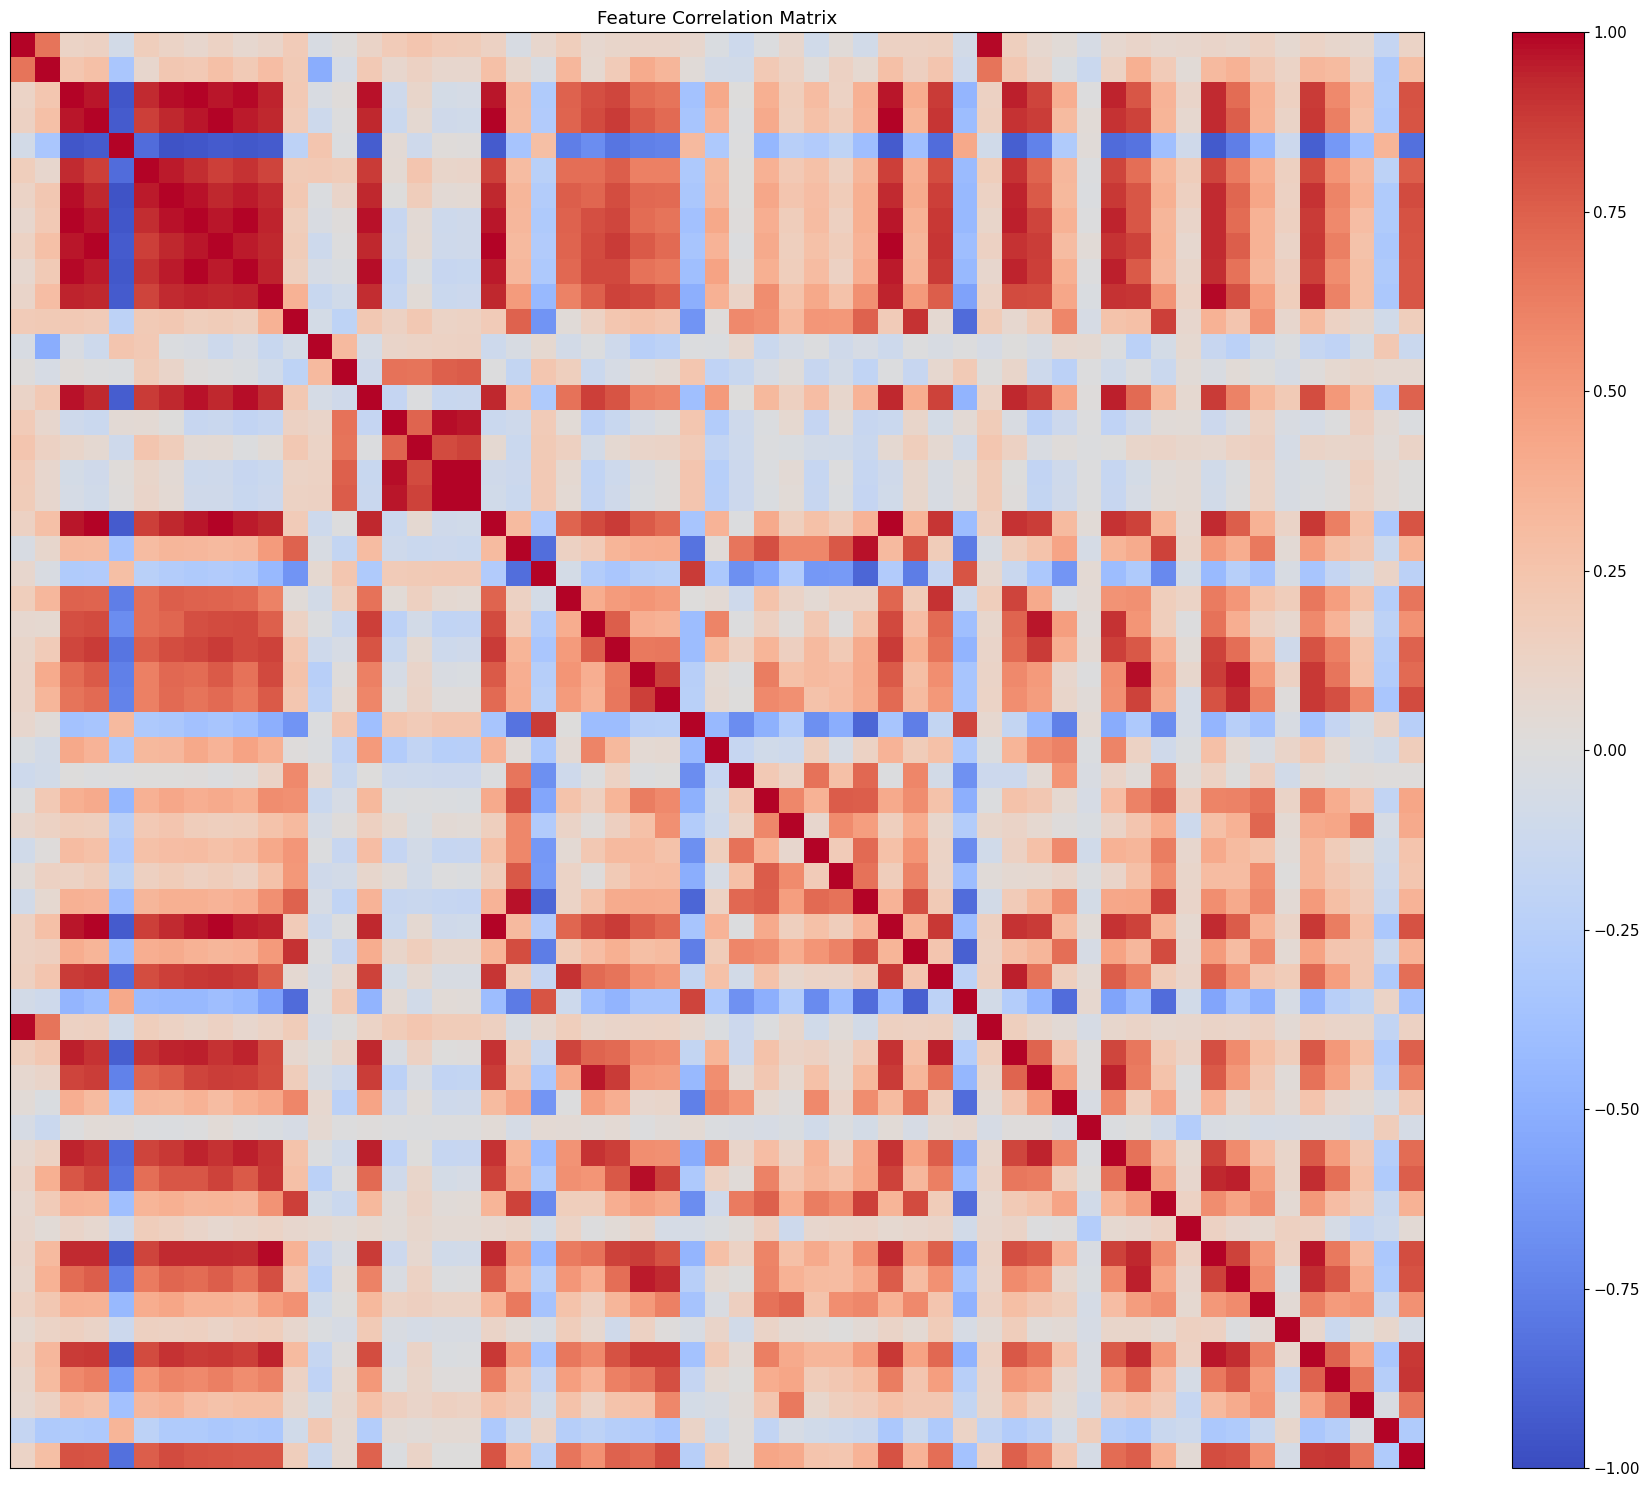


Summary
----------------------------------------
Total Features            : 57
Constant Features         : 0
Near-Zero Variance        : 1
Highly Correlated Pairs   : 43

Top Correlated Feature Pairs


,Feature_A,Feature_B,Correlation
23,variance,hjorth_activity,1.000000
29,variance,total_power,0.999848
33,hjorth_activity,total_power,0.999848
25,energy,hjorth_activity,0.999786
9,variance,energy,0.999786
31,energy,total_power,0.999630
14,rms,absolute_mean,0.997012
21,impulse_factor,clearance_factor,0.996594
5,std,rms,0.996119
11,std,absolute_mean,0.991085


2026-07-19 10:39:17,786 | INFO | Feature Audit Completed.
2026-07-19 10:39:17,787 | INFO | Constant Features : 0
2026-07-19 10:39:17,788 | INFO | Near Zero Variance : 1
2026-07-19 10:39:17,789 | INFO | Highly Correlated Pairs : 43


In [15]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 12 : Feature Audit & Correlation Analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

logger.info("Starting Feature Audit...")

print("=" * 80)
print("Feature Audit & Correlation Analysis")
print("=" * 80)

# ------------------------------------------------------------
# Feature Columns
# ------------------------------------------------------------

metadata_cols = [
    "file",
    "class",
    "label",
    "label_name",
    "binary_label"
]

feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

X = features_df[feature_cols]

print(f"Samples  : {len(X)}")
print(f"Features : {len(feature_cols)}")

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

missing = X.isnull().sum()

print("\nMissing Values")
print("-" * 40)
print(f"Total Missing Values : {missing.sum()}")

# ------------------------------------------------------------
# Constant Features
# ------------------------------------------------------------

constant_features = [
    c for c in feature_cols
    if X[c].nunique() == 1
]

print("\nConstant Features")
print("-" * 40)
print(f"Count : {len(constant_features)}")

# ------------------------------------------------------------
# Near-Zero Variance Features
# ------------------------------------------------------------

variance = X.var()

variance_threshold = 1e-6

low_variance = variance[
    variance < variance_threshold
].sort_values()

print("\nNear-Zero Variance Features")
print("-" * 40)
print(f"Count : {len(low_variance)}")

# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

print("\nComputing Correlation Matrix...")

corr_matrix = X.corr(method="pearson")

# ------------------------------------------------------------
# Highly Correlated Features
# ------------------------------------------------------------

threshold = 0.95

corr_pairs = []

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

for col in upper.columns:

    high_corr = upper[col][
        upper[col].abs() > threshold
    ]

    for idx, value in high_corr.items():

        corr_pairs.append({
            "Feature_A": idx,
            "Feature_B": col,
            "Correlation": value
        })

corr_df = pd.DataFrame(corr_pairs)

print(f"\nHighly Correlated Pairs (>|{threshold}|)")
print("-" * 40)
print(f"Count : {len(corr_df)}")

# ------------------------------------------------------------
# Save Reports
# ------------------------------------------------------------

variance.to_csv(
    DIRS["reports"] / "feature_variance.csv"
)

corr_df.to_csv(
    DIRS["reports"] / "high_correlation_pairs.csv",
    index=False
)

corr_matrix.to_csv(
    DIRS["reports"] / "correlation_matrix.csv"
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(18, 15))

im = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(im)

plt.title("Feature Correlation Matrix")

plt.xticks([])
plt.yticks([])

plt.tight_layout()

plt.savefig(
    DIRS["plots"] / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nSummary")
print("-" * 40)

print(f"Total Features            : {len(feature_cols)}")
print(f"Constant Features         : {len(constant_features)}")
print(f"Near-Zero Variance        : {len(low_variance)}")
print(f"Highly Correlated Pairs   : {len(corr_df)}")

if len(corr_df):

    print("\nTop Correlated Feature Pairs")

    display(
        corr_df.sort_values(
            "Correlation",
            key=np.abs,
            ascending=False
        ).head(20)
    )

logger.info("Feature Audit Completed.")
logger.info(f"Constant Features : {len(constant_features)}")
logger.info(f"Near Zero Variance : {len(low_variance)}")
logger.info(f"Highly Correlated Pairs : {len(corr_df)}")

2026-07-19 10:39:18,658 | INFO | Starting Feature Ranking Analysis...


Feature Ranking & Selection Analysis
Samples  : 500
Features : 57

Computing Mutual Information...
Computing ANOVA F-score...
Training Random Forest for Feature Importance...

Ranking saved to:
/kaggle/working/NeuroAegis/reports/feature_ranking.csv


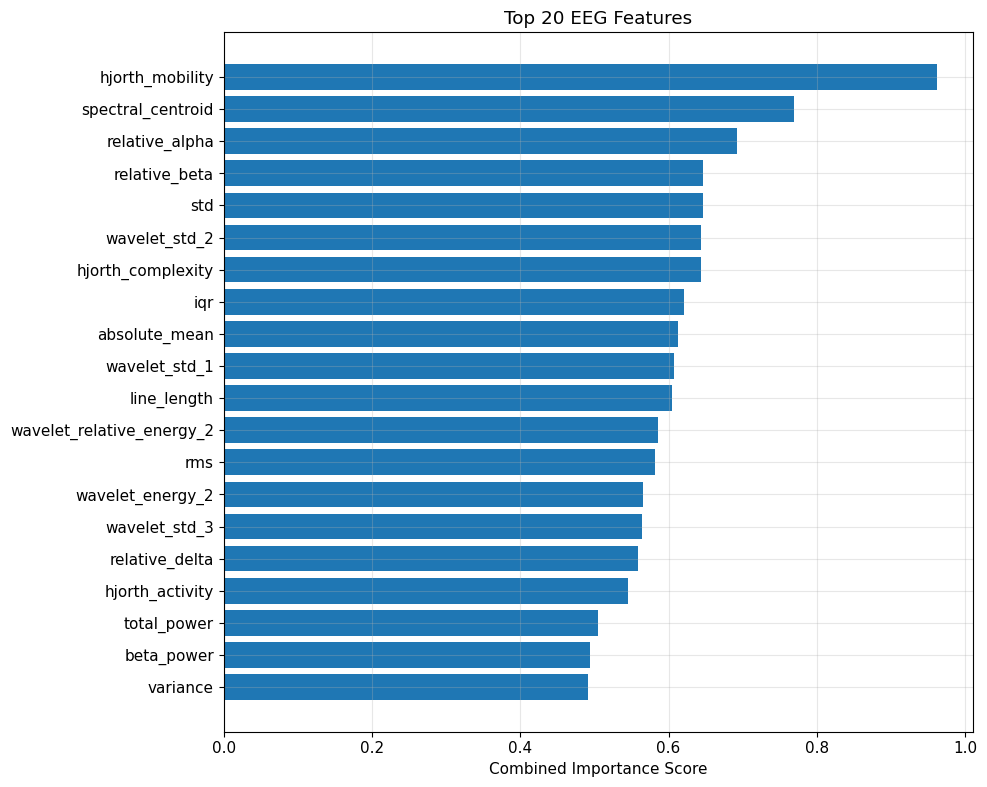


Top 20 Features
------------------------------------------------------------


,Rank,Feature,Combined_Score,Mutual_Information,ANOVA_F,RandomForest_Importance
0,1,hjorth_mobility,0.962288,0.687379,318.608930,0.058189
1,2,spectral_centroid,0.769223,0.626953,272.806271,0.038882
2,3,relative_alpha,0.692007,0.600639,183.171583,0.043589
3,4,relative_beta,0.646877,0.606625,67.509849,0.055631
4,5,std,0.646292,0.620493,248.724214,0.023325
5,6,wavelet_std_2,0.643435,0.763040,156.578396,0.028071
6,7,hjorth_complexity,0.643159,0.505000,176.095839,0.043923
7,8,iqr,0.620340,0.561015,270.647856,0.019731
8,9,absolute_mean,0.613146,0.556299,247.229084,0.022930
9,10,wavelet_std_1,0.607313,0.613118,242.242954,0.018591


2026-07-19 10:39:21,073 | INFO | Feature Ranking Completed.
2026-07-19 10:39:21,075 | INFO | Top Feature : hjorth_mobility
2026-07-19 10:39:21,076 | INFO | Total Ranked Features : 57



Top 10 Features
 1. hjorth_mobility               0.9623
 2. spectral_centroid             0.7692
 3. relative_alpha                0.6920
 4. relative_beta                 0.6469
 5. std                           0.6463
 6. wavelet_std_2                 0.6434
 7. hjorth_complexity             0.6432
 8. iqr                           0.6203
 9. absolute_mean                 0.6131
10. wavelet_std_1                 0.6073


In [16]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 13 : Feature Ranking & Selection Analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

logger.info("Starting Feature Ranking Analysis...")

print("=" * 80)
print("Feature Ranking & Selection Analysis")
print("=" * 80)

# ------------------------------------------------------------
# Prepare Data
# ------------------------------------------------------------

metadata_cols = [
    "file",
    "class",
    "label",
    "label_name",
    "binary_label"
]

feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

X = features_df[feature_cols]
y = features_df["label"]

print(f"Samples  : {X.shape[0]}")
print(f"Features : {X.shape[1]}")

# ------------------------------------------------------------
# Mutual Information
# ------------------------------------------------------------

print("\nComputing Mutual Information...")

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

# ------------------------------------------------------------
# ANOVA F-score
# ------------------------------------------------------------

print("Computing ANOVA F-score...")

f_scores, p_values = f_classif(X, y)

# ------------------------------------------------------------
# Random Forest Importance
# ------------------------------------------------------------

print("Training Random Forest for Feature Importance...")

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

rf_importance = rf.feature_importances_

# ------------------------------------------------------------
# Normalize Scores
# ------------------------------------------------------------

scaler = MinMaxScaler()

mi_norm = scaler.fit_transform(
    mi_scores.reshape(-1,1)
).flatten()

f_norm = scaler.fit_transform(
    f_scores.reshape(-1,1)
).flatten()

rf_norm = scaler.fit_transform(
    rf_importance.reshape(-1,1)
).flatten()

# ------------------------------------------------------------
# Combined Score
# ------------------------------------------------------------

combined_score = (
    mi_norm +
    f_norm +
    rf_norm
) / 3

ranking_df = pd.DataFrame({

    "Feature": feature_cols,

    "Mutual_Information": mi_scores,

    "ANOVA_F": f_scores,

    "RandomForest_Importance": rf_importance,

    "Combined_Score": combined_score

})

ranking_df = ranking_df.sort_values(
    "Combined_Score",
    ascending=False
).reset_index(drop=True)

ranking_df["Rank"] = np.arange(
    1,
    len(ranking_df)+1
)

ranking_df = ranking_df[
    [
        "Rank",
        "Feature",
        "Combined_Score",
        "Mutual_Information",
        "ANOVA_F",
        "RandomForest_Importance"
    ]
]

# ------------------------------------------------------------
# Save Ranking
# ------------------------------------------------------------

ranking_path = DIRS["reports"] / "feature_ranking.csv"

ranking_df.to_csv(
    ranking_path,
    index=False
)

print("\nRanking saved to:")
print(ranking_path)

# ------------------------------------------------------------
# Plot Top 20 Features
# ------------------------------------------------------------

top20 = ranking_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"][::-1],
    top20["Combined_Score"][::-1]
)

plt.xlabel("Combined Importance Score")

plt.title("Top 20 EEG Features")

plt.tight_layout()

plot_path = DIRS["plots"] / "top20_feature_importance.png"

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nTop 20 Features")
print("-"*60)

display(top20)

print("\nTop 10 Features")

for i, row in ranking_df.head(10).iterrows():

    print(
        f"{row['Rank']:2d}. "
        f"{row['Feature']:<30}"
        f"{row['Combined_Score']:.4f}"
    )

logger.info("Feature Ranking Completed.")
logger.info(f"Top Feature : {ranking_df.iloc[0]['Feature']}")
logger.info(f"Total Ranked Features : {len(ranking_df)}")

In [17]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 14 : Prepare Modeling Dataset
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

logger.info("Preparing Modeling Dataset...")

print("=" * 80)
print("Preparing Modeling Dataset")
print("=" * 80)

# ------------------------------------------------------------
# Metadata Columns
# ------------------------------------------------------------

metadata_cols = [
    "file",
    "class",
    "label",
    "label_name",
    "binary_label"
]

feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

X = features_df[feature_cols]
y = features_df["label"]

print(f"Original Features : {X.shape[1]}")

# ------------------------------------------------------------
# Remove Near-Zero Variance Features
# ------------------------------------------------------------

selector = VarianceThreshold(threshold=1e-6)

X_filtered = selector.fit_transform(X)

selected_features = np.array(feature_cols)[
    selector.get_support()
]

removed_features = np.array(feature_cols)[
    ~selector.get_support()
]

print(f"Removed Features : {len(removed_features)}")
print(f"Remaining Features : {len(selected_features)}")

if len(removed_features):
    print("\nRemoved:")
    for f in removed_features:
        print(f"  - {f}")

# ------------------------------------------------------------
# Train / Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nDataset Shapes")
print("-" * 40)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

# ------------------------------------------------------------
# Class Distribution
# ------------------------------------------------------------

print("\nTraining Distribution")

display(
    y_train.value_counts().sort_index()
)

print("\nTesting Distribution")

display(
    y_test.value_counts().sort_index()
)

# ------------------------------------------------------------
# Save Split
# ------------------------------------------------------------

np.savez_compressed(
    DIRS["features"] / "train_test_split.npz",
    X_train=X_train.astype(np.float32),
    X_test=X_test.astype(np.float32),
    y_train=y_train.values.astype(np.int64),
    y_test=y_test.values.astype(np.int64)
)

with open(
    DIRS["features"] / "selected_features.json",
    "w"
) as f:
    json.dump(selected_features.tolist(), f, indent=4)

print("\nSaved Files")
print("-" * 40)

print(DIRS["features"] / "train_test_split.npz")
print(DIRS["features"] / "selected_features.json")

logger.info("Modeling Dataset Ready.")
logger.info(f"Training Shape : {X_train.shape}")
logger.info(f"Testing Shape : {X_test.shape}")

2026-07-19 10:39:21,088 | INFO | Preparing Modeling Dataset...


Preparing Modeling Dataset
Original Features : 57
Removed Features : 1
Remaining Features : 56

Removed:
  - wavelet_relative_energy_4

Dataset Shapes
----------------------------------------
Train : (400, 56)
Test  : (100, 56)

Training Distribution


label
0    80
1    80
2    80
3    80
4    80
Name: count, dtype: int64


Testing Distribution


label
0    20
1    20
2    20
3    20
4    20
Name: count, dtype: int64

2026-07-19 10:39:21,113 | INFO | Modeling Dataset Ready.
2026-07-19 10:39:21,113 | INFO | Training Shape : (400, 56)
2026-07-19 10:39:21,114 | INFO | Testing Shape : (100, 56)



Saved Files
----------------------------------------
/kaggle/working/NeuroAegis/features/train_test_split.npz
/kaggle/working/NeuroAegis/features/selected_features.json


In [18]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 14 : Model Evaluation Utilities
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

CLASS_NAMES = [
    "Healthy",
    "Eyes Closed",
    "Interictal",
    "Preictal",
    "Seizure"
]

N_CLASSES = len(CLASS_NAMES)


# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(
    model,
    X_test,
    y_test,
    model_name="Model"
):

    print("=" * 80)
    print(f"{model_name} Evaluation")
    print("=" * 80)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_test)

    y_prob = None

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics = {

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(
                y_test,
                y_pred,
                average="macro"
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred,
                average="macro"
            ),

        "F1":
            f1_score(
                y_test,
                y_pred,
                average="macro"
            ),

        "Cohen_Kappa":
            cohen_kappa_score(
                y_test,
                y_pred
            ),

        "MCC":
            matthews_corrcoef(
                y_test,
                y_pred
            )

    }

    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    if y_prob is not None:

        y_test_bin = label_binarize(
            y_test,
            classes=np.arange(N_CLASSES)
        )

        metrics["ROC_AUC"] = roc_auc_score(
            y_test_bin,
            y_prob,
            average="macro",
            multi_class="ovr"
        )

    # --------------------------------------------------------
    # Print Metrics
    # --------------------------------------------------------

    print("\nPerformance Metrics")
    print("-"*40)

    for k, v in metrics.items():
        print(f"{k:<15}: {v:.4f}")

    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    print("\nClassification Report")
    print("-"*40)

    print(

        classification_report(

            y_test,
            y_pred,

            target_names=CLASS_NAMES,

            digits=4

        )

    )

    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    fig, ax = plt.subplots(figsize=(8,8))

    ConfusionMatrixDisplay(

        confusion_matrix=cm,
        display_labels=CLASS_NAMES

    ).plot(

        cmap="Blues",
        ax=ax,
        colorbar=False

    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.tight_layout()

    plt.savefig(

        DIRS["plots"] /
        f"{model_name.lower().replace(' ','_')}_confusion_matrix.png",

        dpi=300

    )

    plt.show()

    # --------------------------------------------------------
    # ROC Curves
    # --------------------------------------------------------

    if y_prob is not None:

        plt.figure(figsize=(8,8))

        y_test_bin = label_binarize(
            y_test,
            classes=np.arange(N_CLASSES)
        )

        for i in range(N_CLASSES):

            fpr, tpr, _ = roc_curve(
                y_test_bin[:, i],
                y_prob[:, i]
            )

            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.3f})"
            )

        plt.plot(
            [0,1],
            [0,1],
            "--",
            color="black"
        )

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"{model_name} ROC Curves")

        plt.legend()

        plt.grid(alpha=0.3)

        plt.tight_layout()

        plt.savefig(

            DIRS["plots"] /
            f"{model_name.lower().replace(' ','_')}_roc_curve.png",

            dpi=300

        )

        plt.show()

    # --------------------------------------------------------
    # Save Metrics
    # --------------------------------------------------------

    metric_df = pd.DataFrame({

        "Metric": metrics.keys(),
        "Value": metrics.values()

    })

    metric_df.to_csv(

        DIRS["reports"] /
        f"{model_name.lower().replace(' ','_')}_metrics.csv",

        index=False

    )

    return metrics

2026-07-19 10:41:42,111 | INFO | Training Baseline Random Forest...


Baseline Random Forest
Running 5-Fold Cross Validation...

Cross Validation Results
----------------------------------------
Accuracy  : 0.8550 ± 0.0061
Precision : 0.8624 ± 0.0067
Recall    : 0.8550 ± 0.0061
F1        : 0.8538 ± 0.0070
Random Forest Evaluation

Performance Metrics
----------------------------------------
Accuracy       : 0.8500
Precision      : 0.8546
Recall         : 0.8500
F1             : 0.8518
Cohen_Kappa    : 0.8125
MCC            : 0.8128
ROC_AUC        : 0.9794

Classification Report
----------------------------------------
              precision    recall  f1-score   support

     Healthy     1.0000    0.9500    0.9744        20
 Eyes Closed     0.9500    0.9500    0.9500        20
  Interictal     0.7368    0.7000    0.7179        20
    Preictal     0.6364    0.7000    0.6667        20
     Seizure     0.9500    0.9500    0.9500        20

    accuracy                         0.8500       100
   macro avg     0.8546    0.8500    0.8518       100
weighted a

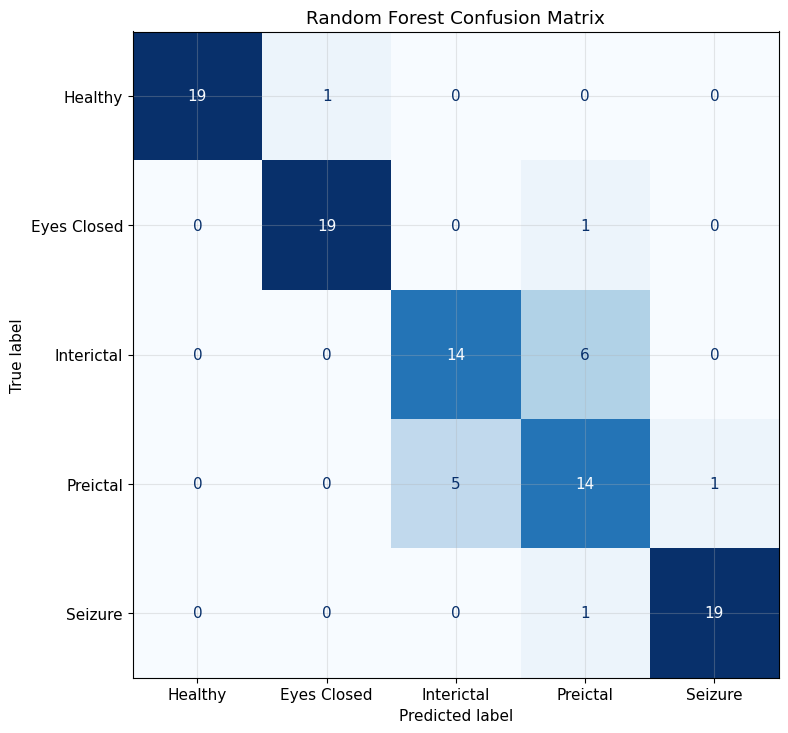

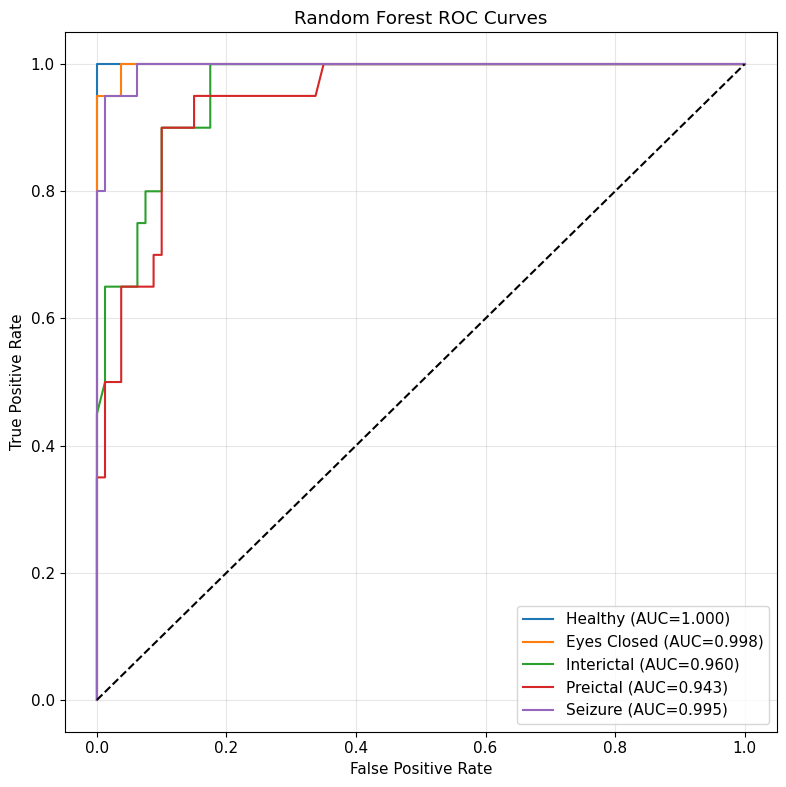

2026-07-19 10:41:48,734 | INFO | Random Forest Training Completed.
2026-07-19 10:41:48,735 | INFO | Test Accuracy : 0.8500
2026-07-19 10:41:48,872 | INFO | Random Forest Model Saved : /kaggle/working/NeuroAegis/models/random_forest_baseline.pkl



Model Saved
/kaggle/working/NeuroAegis/models/random_forest_baseline.pkl


In [20]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 15 : Baseline Random Forest
# ============================================================

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

logger.info("Training Baseline Random Forest...")

print("=" * 80)
print("Baseline Random Forest")
print("=" * 80)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 5-Fold Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

print("Running 5-Fold Cross Validation...")

cv_results = cross_validate(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\nCross Validation Results")
print("-" * 40)

for metric in scoring.keys():

    values = cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():<10}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )
# ------------------------------------------------------------
# Store Cross Validation Results
# ------------------------------------------------------------

rf_cv_results = {

    "Accuracy": cv_results["test_accuracy"].mean(),
    "Accuracy_std": cv_results["test_accuracy"].std(),

    "Precision": cv_results["test_precision"].mean(),
    "Precision_std": cv_results["test_precision"].std(),

    "Recall": cv_results["test_recall"].mean(),
    "Recall_std": cv_results["test_recall"].std(),

    "F1": cv_results["test_f1"].mean(),
    "F1_std": cv_results["test_f1"].std()

}
# ------------------------------------------------------------
# Train Final Model
# ------------------------------------------------------------

rf.fit(X_train, y_train)

# # ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------

rf_results = evaluate_model(
    rf,
    X_test,
    y_test,
    model_name="Random Forest"
)

logger.info("Random Forest Training Completed.")
logger.info(
    f"Test Accuracy : {rf_results['Accuracy']:.4f}"
)
# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

joblib.dump(
    rf,
    DIRS["models"] / "random_forest_baseline.pkl"
)

print("\nModel Saved")
print(DIRS["models"] / "random_forest_baseline.pkl")

logger.info(
    f"Random Forest Model Saved : {DIRS['models'] / 'random_forest_baseline.pkl'}"
)

2026-07-19 10:41:53,174 | INFO | Training Baseline XGBoost...


Baseline XGBoost
Running 5-Fold Cross Validation...

Cross Validation Results
----------------------------------------
Accuracy  : 0.8500 ± 0.0237
Precision : 0.8566 ± 0.0224
Recall    : 0.8500 ± 0.0237
F1        : 0.8485 ± 0.0231

Training Final Model...
XGBoost Evaluation

Performance Metrics
----------------------------------------
Accuracy       : 0.8800
Precision      : 0.8829
Recall         : 0.8800
F1             : 0.8812
Cohen_Kappa    : 0.8500
MCC            : 0.8501
ROC_AUC        : 0.9846

Classification Report
----------------------------------------
              precision    recall  f1-score   support

     Healthy     1.0000    0.9500    0.9744        20
 Eyes Closed     0.9500    0.9500    0.9500        20
  Interictal     0.8000    0.8000    0.8000        20
    Preictal     0.7143    0.7500    0.7317        20
     Seizure     0.9500    0.9500    0.9500        20

    accuracy                         0.8800       100
   macro avg     0.8829    0.8800    0.8812       1

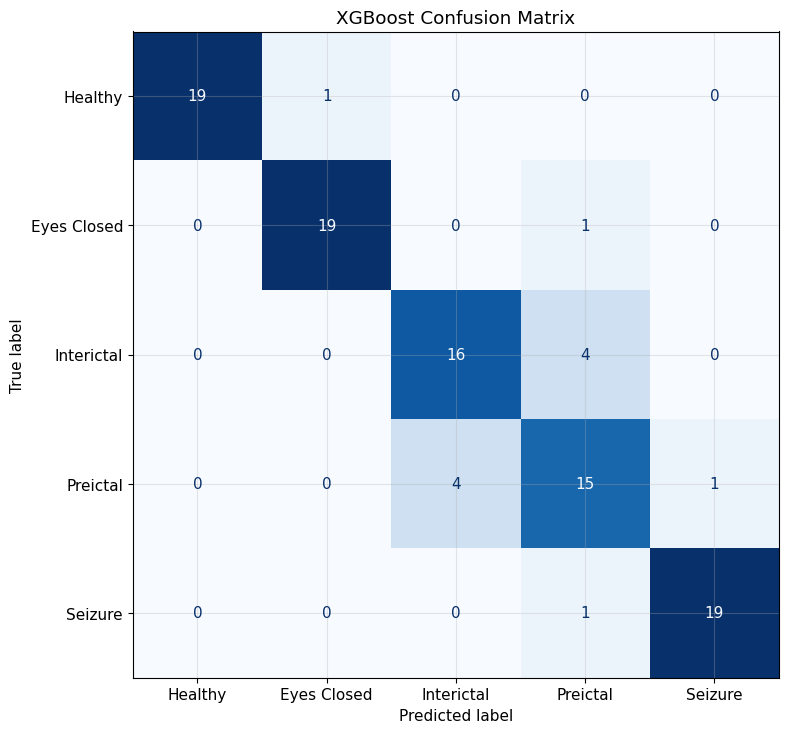

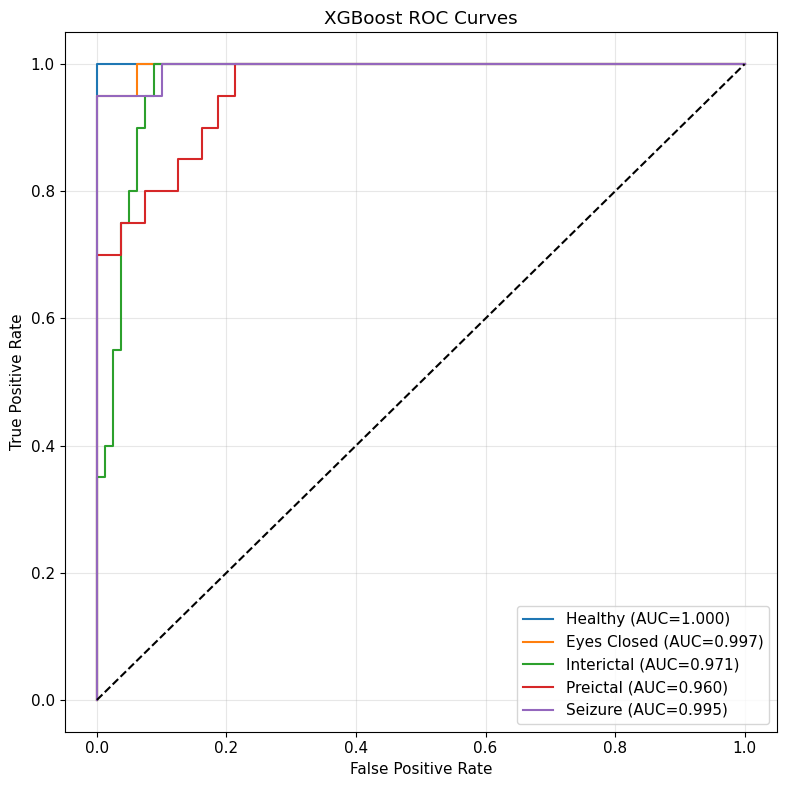

2026-07-19 10:41:59,210 | INFO | XGBoost Training Completed.
2026-07-19 10:41:59,211 | INFO | Accuracy : 0.8800



Model Saved
/kaggle/working/NeuroAegis/models/xgboost_baseline.pkl


In [21]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 16 : Baseline XGBoost
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

logger.info("Training Baseline XGBoost...")

print("=" * 80)
print("Baseline XGBoost")
print("=" * 80)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

xgb = XGBClassifier(

    objective="multi:softprob",
    num_class=5,

    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=1,

    gamma=0,

    reg_alpha=0,
    reg_lambda=1,

    tree_method="hist",

    eval_metric="mlogloss",

    random_state=42,

    n_jobs=-1

)

# ------------------------------------------------------------
# 5-Fold Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

print("Running 5-Fold Cross Validation...")

cv_results = cross_validate(

    xgb,

    X_train,
    y_train,

    cv=cv,

    scoring=scoring,

    n_jobs=-1

)

print("\nCross Validation Results")
print("-"*40)

for metric in scoring:

    values = cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():<10}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

# ------------------------------------------------------------
# Train Final Model
# ------------------------------------------------------------

print("\nTraining Final Model...")

xgb.fit(
    X_train,
    y_train
)
# ------------------------------------------------------------
# Store Cross Validation Results
# ------------------------------------------------------------

xgb_cv_results = {

    "Accuracy": cv_results["test_accuracy"].mean(),
    "Accuracy_std": cv_results["test_accuracy"].std(),

    "Precision": cv_results["test_precision"].mean(),
    "Precision_std": cv_results["test_precision"].std(),

    "Recall": cv_results["test_recall"].mean(),
    "Recall_std": cv_results["test_recall"].std(),

    "F1": cv_results["test_f1"].mean(),
    "F1_std": cv_results["test_f1"].std()

}
# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

xgb_results = evaluate_model(

    xgb,

    X_test,

    y_test,

    model_name="XGBoost"

)

logger.info("XGBoost Training Completed.")

logger.info(
    f"Accuracy : {xgb_results['Accuracy']:.4f}"
)

# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

import joblib

joblib.dump(
    xgb,
    DIRS["models"] / "xgboost_baseline.pkl"
)

print("\nModel Saved")

print(DIRS["models"] / "xgboost_baseline.pkl")

2026-07-19 10:42:06,998 | INFO | Training Baseline LightGBM...


Baseline LightGBM
Running 5-Fold Cross Validation...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Cross Validation Results
----------------------------------------
Accuracy  : 0.8575 ± 0.0245
Precision : 0.8636 ± 0.0230
Recall    : 0.8575 ± 0.0245
F1        : 0.8554 ± 0.0248

Training Final Model...
LightGBM Evaluation

Performance Metrics
----------------------------------------
Accuracy       : 0.9000
Precision      : 0.9015
Recall         : 0.9000
F1             : 0.9001
Cohen_Kappa    : 0.8750
MCC            : 0.8753
ROC_AUC        : 0.9844

Classification Report
----------------------------------------
              precision    recall  f1-score   support

     Healthy     1.0000    0.9500    0.9744        20
 Eyes Closed     0.9500    0.9500    0.9500        20
  Interictal     0.8182    0.9000    0.8571        20
    Preictal     0.7895    0.7500    0.7692        20
     Seizure     0.9500    0.9500    0.9500        20

    accuracy                         0.9000       100
   macro avg     0.9015    0.9000    0.9001       100
weighted avg     0.9015    0.9000    0.9001     

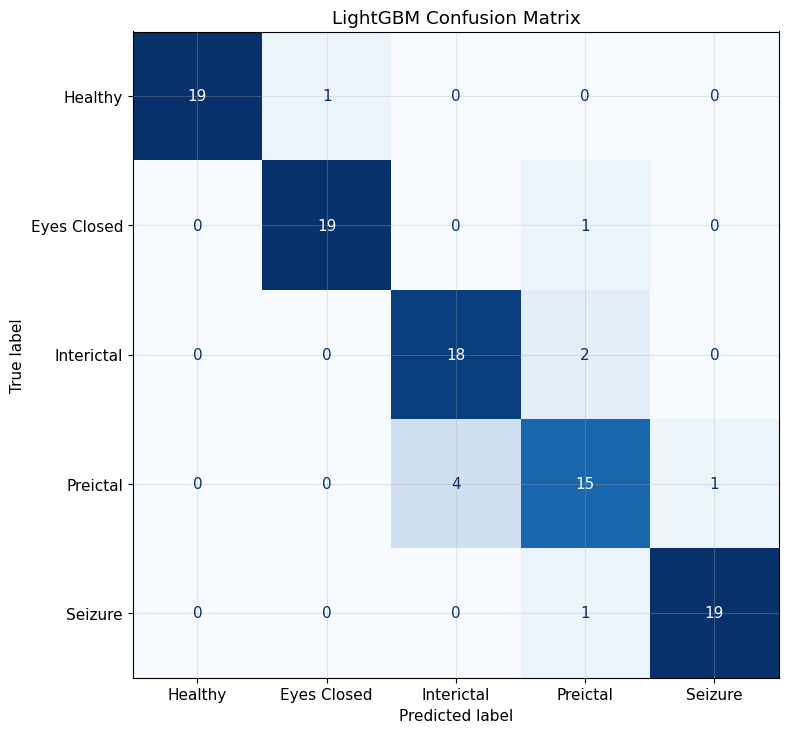

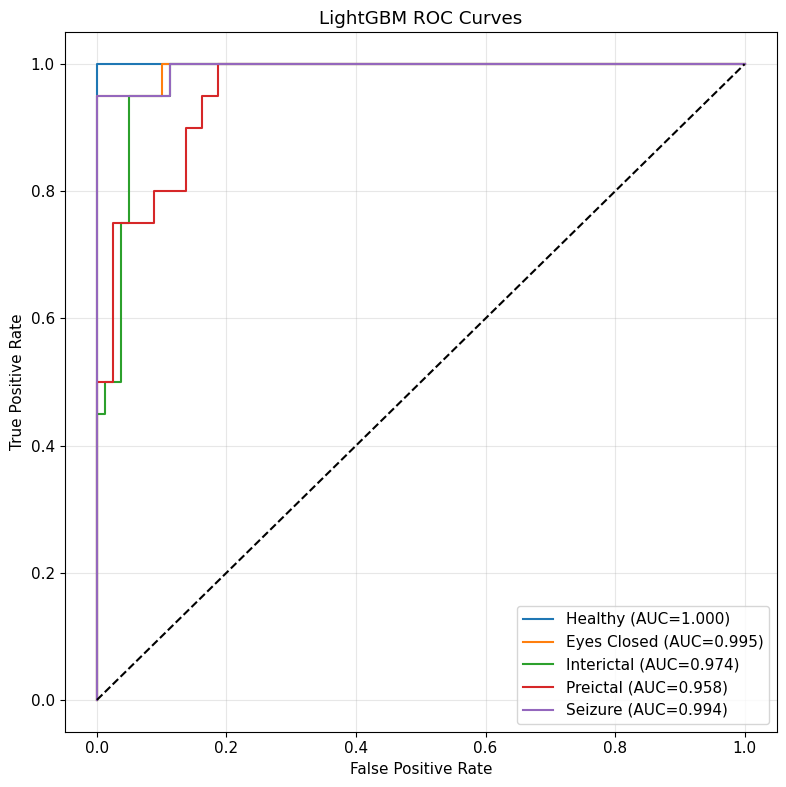

2026-07-19 10:47:14,828 | INFO | LightGBM Training Completed.
2026-07-19 10:47:14,829 | INFO | Accuracy : 0.9000
2026-07-19 10:47:14,868 | INFO | LightGBM Model Saved : /kaggle/working/NeuroAegis/models/lightgbm_baseline.pkl



Model Saved
/kaggle/working/NeuroAegis/models/lightgbm_baseline.pkl


In [22]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 17 : Baseline LightGBM
# ============================================================

import numpy as np
import pandas as pd
import joblib

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

logger.info("Training Baseline LightGBM...")

print("=" * 80)
print("Baseline LightGBM")
print("=" * 80)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

lgbm = LGBMClassifier(

    objective="multiclass",

    num_class=5,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_samples=20,

    reg_alpha=0.0,

    reg_lambda=1.0,

    random_state=42,

    n_jobs=-1,

    verbosity=-1

)

# ------------------------------------------------------------
# 5-Fold Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

scoring = {

    "accuracy": "accuracy",

    "precision": "precision_macro",

    "recall": "recall_macro",

    "f1": "f1_macro"

}

print("Running 5-Fold Cross Validation...")

cv_results = cross_validate(

    lgbm,

    X_train,

    y_train,

    cv=cv,

    scoring=scoring,

    n_jobs=-1

)

print("\nCross Validation Results")
print("-" * 40)

for metric in scoring:

    values = cv_results[f"test_{metric}"]

    print(

        f"{metric.capitalize():<10}: "

        f"{values.mean():.4f} ± {values.std():.4f}"

    )

# ------------------------------------------------------------
# Train Final Model
# ------------------------------------------------------------

print("\nTraining Final Model...")

lgbm.fit(

    X_train,

    y_train

)
# ------------------------------------------------------------
# Store Cross Validation Results
# ------------------------------------------------------------

lgbm_cv_results = {

    "Accuracy": cv_results["test_accuracy"].mean(),
    "Accuracy_std": cv_results["test_accuracy"].std(),

    "Precision": cv_results["test_precision"].mean(),
    "Precision_std": cv_results["test_precision"].std(),

    "Recall": cv_results["test_recall"].mean(),
    "Recall_std": cv_results["test_recall"].std(),

    "F1": cv_results["test_f1"].mean(),
    "F1_std": cv_results["test_f1"].std()

}

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

lgbm_results = evaluate_model(

    lgbm,

    X_test,

    y_test,

    model_name="LightGBM"

)

logger.info("LightGBM Training Completed.")

logger.info(

    f"Accuracy : {lgbm_results['Accuracy']:.4f}"

)

# ------------------------------------------------------------
# Save Model Artifact
# ------------------------------------------------------------

joblib.dump(

    {

        "model": lgbm,

        "feature_names": selected_features,

        "class_names": CLASS_NAMES,

        "metrics": lgbm_results

    },

    DIRS["models"] / "lightgbm_baseline.pkl"

)

print("\nModel Saved")

print(

    DIRS["models"] / "lightgbm_baseline.pkl"

)

logger.info(

    f"LightGBM Model Saved : {DIRS['models'] / 'lightgbm_baseline.pkl'}"

)

2026-07-19 10:50:02,154 | INFO | Comparing Baseline Models...


Baseline Model Comparison

Performance Comparison
--------------------------------------------------------------------------------


,Model,CV Accuracy,CV Std,Accuracy,Precision,Recall,F1,Kappa,MCC,ROC_AUC
0,Random Forest,0.8550,0.0061,0.85,0.8546,0.85,0.8518,0.8125,0.8128,0.9794
1,XGBoost,0.8500,0.0237,0.88,0.8829,0.88,0.8812,0.8500,0.8501,0.9846
2,LightGBM,0.8575,0.0245,0.90,0.9015,0.90,0.9001,0.8750,0.8753,0.9844



Saved:
/kaggle/working/NeuroAegis/reports/model_comparison.csv

Best Baseline Model
----------------------------------------
Model    : LightGBM
Accuracy : 0.9000

Best model saved as:
/kaggle/working/NeuroAegis/models/best_baseline_model.pkl


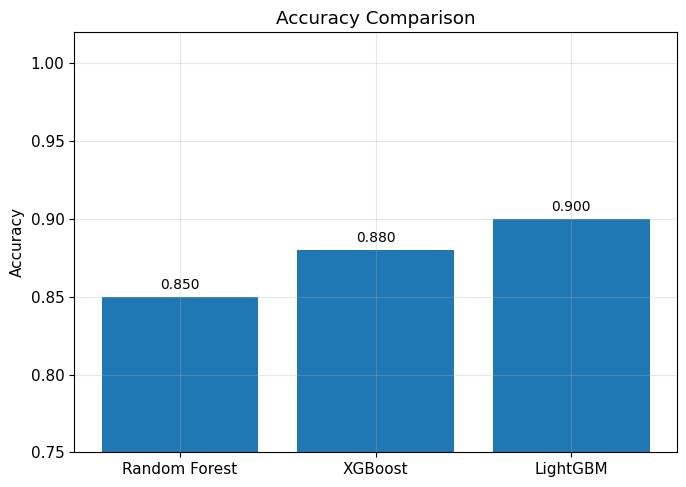

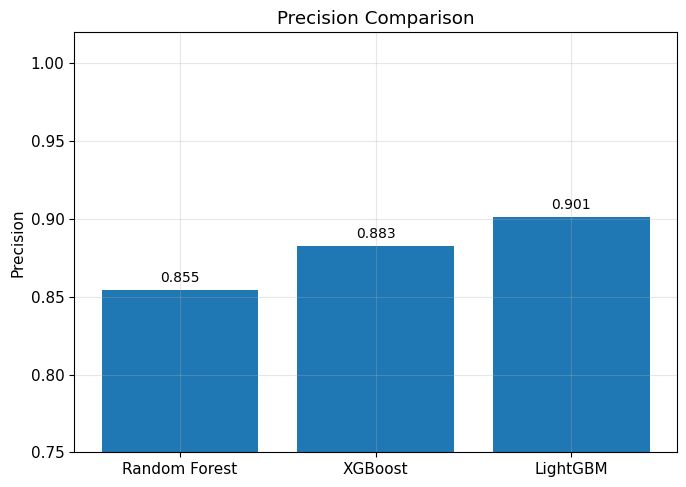

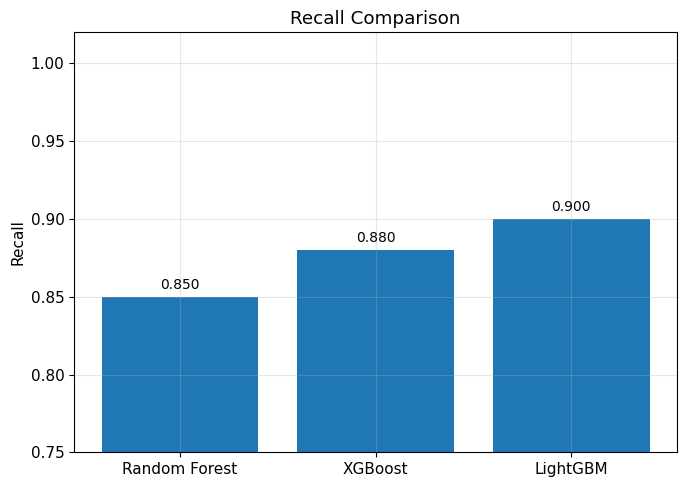

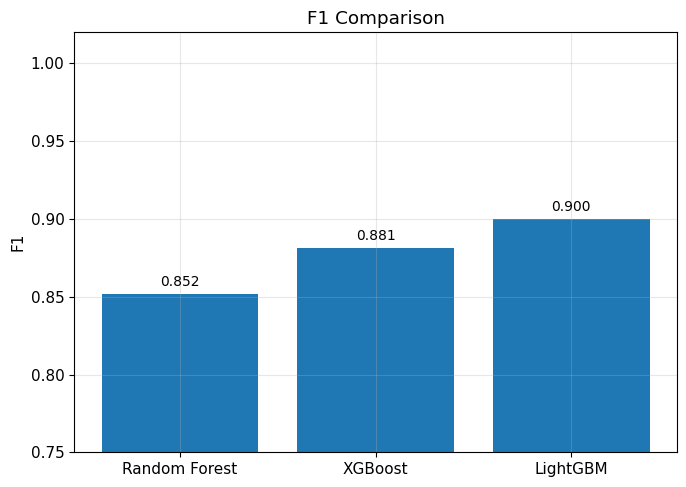

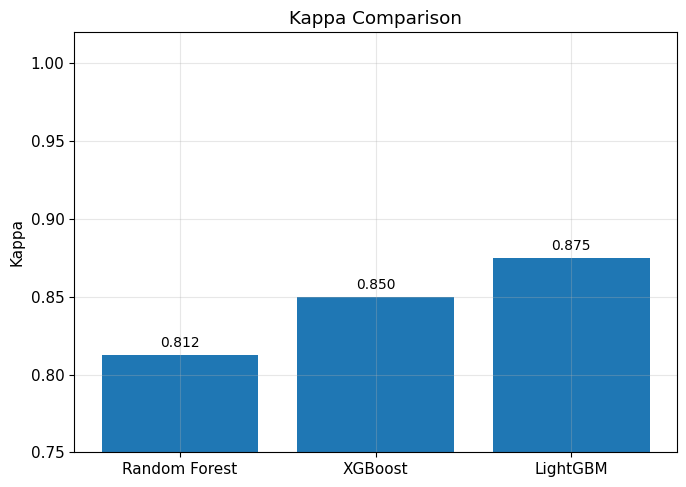

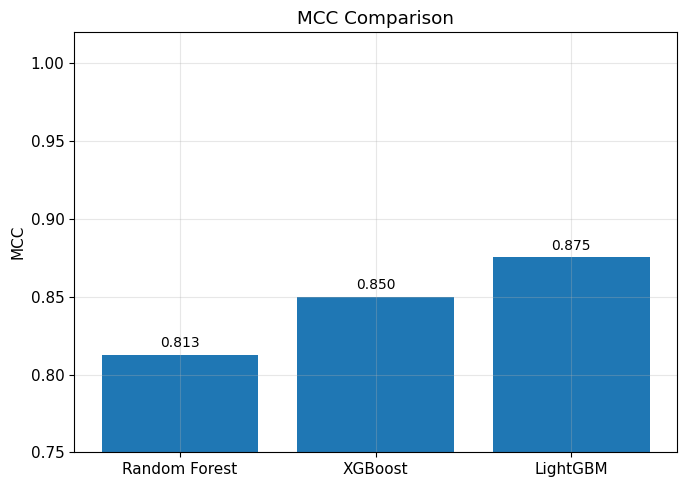

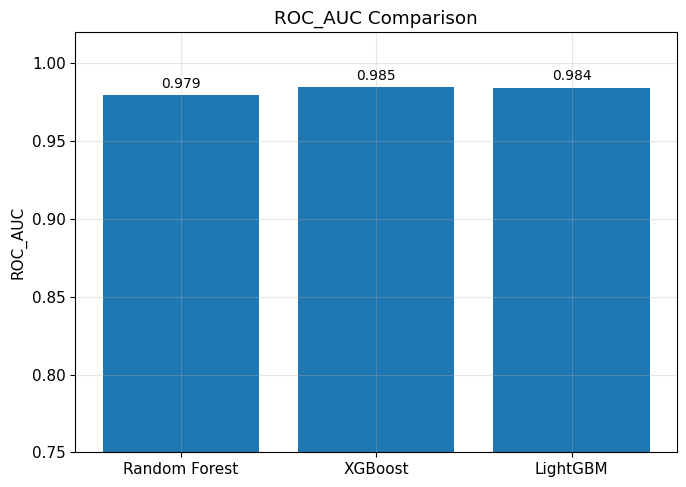


Model Ranking
--------------------------------------------------------------------------------


,Model,CV Accuracy,CV Std,Accuracy,Precision,Recall,F1,Kappa,MCC,ROC_AUC
0,LightGBM,0.8575,0.0245,0.90,0.9015,0.90,0.9001,0.8750,0.8753,0.9844
1,XGBoost,0.8500,0.0237,0.88,0.8829,0.88,0.8812,0.8500,0.8501,0.9846
2,Random Forest,0.8550,0.0061,0.85,0.8546,0.85,0.8518,0.8125,0.8128,0.9794


2026-07-19 10:50:04,511 | INFO | Model Comparison Completed.
2026-07-19 10:50:04,512 | INFO | Best Baseline Model : LightGBM


In [24]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 18 : Baseline Model Comparison
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import joblib

logger.info("Comparing Baseline Models...")

print("=" * 80)
print("Baseline Model Comparison")
print("=" * 80)

# ------------------------------------------------------------
# Collect Results
# ------------------------------------------------------------

models = [

    (
        "Random Forest",
        rf_results,
        rf_cv_results,
        "random_forest_baseline.pkl"
    ),

    (
        "XGBoost",
        xgb_results,
        xgb_cv_results,
        "xgboost_baseline.pkl"
    ),

    (
        "LightGBM",
        lgbm_results,
        lgbm_cv_results,
        "lightgbm_baseline.pkl"
    )

]

rows = []

for name, metrics, cv, model_file in models:

    rows.append({

        "Model": name,

        "CV Accuracy": cv["Accuracy"],
        "CV Std": cv["Accuracy_std"],

        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "Kappa": metrics["Cohen_Kappa"],
        "MCC": metrics["MCC"],
        "ROC_AUC": metrics["ROC_AUC"]

    })

comparison = pd.DataFrame(rows).round(4)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nPerformance Comparison")
print("-" * 80)

display(comparison)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

comparison.to_csv(
    DIRS["reports"] / "model_comparison.csv",
    index=False
)

print("\nSaved:")
print(DIRS["reports"] / "model_comparison.csv")

# ------------------------------------------------------------
# Select Best Model
# ------------------------------------------------------------

best_idx = comparison["Accuracy"].idxmax()

best_model = comparison.loc[best_idx, "Model"]

best_accuracy = comparison.loc[best_idx, "Accuracy"]

print("\nBest Baseline Model")
print("-" * 40)

print(f"Model    : {best_model}")
print(f"Accuracy : {best_accuracy:.4f}")

# ------------------------------------------------------------
# Save Best Baseline Model
# ------------------------------------------------------------

model_paths = {

    "Random Forest":
        "random_forest_baseline.pkl",

    "XGBoost":
        "xgboost_baseline.pkl",

    "LightGBM":
        "lightgbm_baseline.pkl"

}

best_artifact = joblib.load(
    DIRS["models"] / model_paths[best_model]
)

joblib.dump(

    best_artifact,

    DIRS["models"] / "best_baseline_model.pkl"

)

print("\nBest model saved as:")
print(DIRS["models"] / "best_baseline_model.pkl")

# ------------------------------------------------------------
# Performance Charts
# ------------------------------------------------------------

plot_metrics = [

    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Kappa",
    "MCC",
    "ROC_AUC"

]

for metric in plot_metrics:

    plt.figure(figsize=(7,5))

    bars = plt.bar(
        comparison["Model"],
        comparison[metric]
    )

    plt.ylim(0.75, 1.02)

    plt.ylabel(metric)

    plt.title(f"{metric} Comparison")

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            fontsize=10
        )

    plt.tight_layout()

    plt.savefig(

        DIRS["plots"] /
        f"{metric.lower()}_comparison.png",

        dpi=300

    )

    plt.show()

# ------------------------------------------------------------
# Ranking
# ------------------------------------------------------------

print("\nModel Ranking")
print("-" * 80)

display(
    comparison.sort_values(
        by="Accuracy",
        ascending=False
    ).reset_index(drop=True)
)

logger.info("Model Comparison Completed.")
logger.info(f"Best Baseline Model : {best_model}")

In [ ]:
# ============================================================
# NeuroAegis - EEG Seizure Detection
# Cell 19 : LightGBM Hyperparameter Optimization
# ============================================================

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import pandas as pd
import joblib

logger.info("Starting LightGBM Hyperparameter Optimization...")

print("=" * 80)
print("LightGBM Hyperparameter Optimization")
print("=" * 80)

# ------------------------------------------------------------
# Hyperparameter Search Space
# ------------------------------------------------------------

param_dist = {

    "n_estimators": [100, 200, 300, 500, 700],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.07,
        0.10,
        0.15
    ],

    "num_leaves": [
        15,
        31,
        63,
        127
    ],

    "max_depth": [
        -1,
        4,
        6,
        8,
        10,
        12
    ],

    "min_child_samples": [
        5,
        10,
        20,
        30,
        50
    ],

    "subsample": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        0.5,
        1
    ],

    "reg_lambda": [
        0,
        0.1,
        0.5,
        1,
        2,
        5
    ]

}

# ------------------------------------------------------------
# Base Model
# ------------------------------------------------------------

lgbm = LGBMClassifier(

    objective="multiclass",

    num_class=len(set(y_train)),

    random_state=42,

    n_jobs=-1,

    verbosity=-1

)

# ------------------------------------------------------------
# Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

# ------------------------------------------------------------
# Random Search
# ------------------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=lgbm,

    param_distributions=param_dist,

    n_iter=50,

    scoring="accuracy",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=2,

    refit=True,

    return_train_score=True

)

random_search.fit(X_train, y_train)

# ------------------------------------------------------------
# Best Parameters
# ------------------------------------------------------------

print("\nBest Parameters")
print("-" * 60)

for key, value in random_search.best_params_.items():

    print(f"{key:<22}: {value}")

print("\nBest CV Accuracy")
print("-" * 60)

print(f"{random_search.best_score_:.4f}")

# ------------------------------------------------------------
# Optimized Model
# ------------------------------------------------------------

best_lgbm = random_search.best_estimator_

# ------------------------------------------------------------
# Test Evaluation
# ------------------------------------------------------------

optimized_results = evaluate_model(

    best_lgbm,

    X_test,

    y_test,

    model_name="LightGBM Optimized"

)

# ------------------------------------------------------------
# Save CV Results
# ------------------------------------------------------------

search_results = pd.DataFrame(random_search.cv_results_)

search_results.to_csv(

    DIRS["reports"] /
    "lightgbm_random_search_results.csv",

    index=False

)

# ------------------------------------------------------------
# Save Optimized Model
# ------------------------------------------------------------

artifact = {

    "model": best_lgbm,

    "best_params": random_search.best_params_,

    "cv_accuracy": random_search.best_score_,

    "metrics": optimized_results,

    "feature_names": selected_features,

    "class_names": CLASS_NAMES

}

joblib.dump(

    artifact,

    DIRS["models"] /
    "lightgbm_optimized.pkl"

)

# ------------------------------------------------------------
# Improvement Summary
# ------------------------------------------------------------

print("\nPerformance Comparison")
print("-" * 60)

print(f"Baseline Accuracy  : {lgbm_results['Accuracy']:.4f}")
print(f"Optimized Accuracy : {optimized_results['Accuracy']:.4f}")

delta = optimized_results["Accuracy"] - lgbm_results["Accuracy"]

print(f"Improvement        : {delta:+.4f}")

# ------------------------------------------------------------
# Save Files
# ------------------------------------------------------------

print("\nSaved Files")
print("-" * 60)

print(DIRS["models"] / "lightgbm_optimized.pkl")
print(DIRS["reports"] / "lightgbm_random_search_results.csv")

logger.info("LightGBM Hyperparameter Optimization Completed.")

2026-07-19 10:56:19,284 | INFO | Starting LightGBM Hyperparameter Optimization...


LightGBM Hyperparameter Optimization
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut